# 🎵 Enhanced Comparative VAE Music Clustering — Medium Task
### Conv2D-VAE + Hybrid Features (Spectrogram + Lyrics) + Multi-Algorithm Clustering

| Component | Details |
|-----------|---------|
| 🏗️ **MLP-VAE** | Standard fully-connected VAE baseline |
| 🌀 **Conv2D-VAE** | Conv2D encoder on MFCC spectrogram images |
| 📝 **Hybrid Features** | Audio spectrogram + TF-IDF lyrics embeddings (L2-fused) |
| 🔢 **3 Clustering Algos** | K-Means · Agglomerative · DBSCAN |
| 📊 **5 Metrics** | Silhouette · Davies-Bouldin · Calinski-Harabasz · ARI · NMI |
| 🗺️ **Visualizations** | t-SNE + UMAP · Cluster Composition · Language Separation · Elbow |
| 🇧🇩 **Bangla** | **Real** Bangla audio downloaded via `yt-dlp`, features via `librosa` |

**Datasets:**
- **GTZAN** (George Tzanetakis) — English multi-genre real audio (.wav)
- **BanglaGITI** — Bengali song dataset (Kaggle, real audio)
- **BMGCD** (Bangla Music Genre Classification Dataset) — Bengali multi-genre (Kaggle, real audio)

---
## 🔧 Bug-Fix Log (v2 — addresses all 5 identified issues)

| # | Issue | Fix Applied |
|---|-------|-------------|
| 1 | **`make_hybrid()` undefined** — hard crash in Step 11 | Defined in new Step 4b cell with TF-IDF + LSA + L2 fusion |
| 2 | **`N_PER_GENRE = 5`** — only 50 GTZAN samples, statistically unreliable | Raised to `N_PER_GENRE = 100` (full GTZAN); `MIN_SAMPLES_FOR_METRICS = 30` guard added |
| 3 | **Dead commented-out code block** in Step 9 (cell 19) | Removed entirely; single clean active cell remains |
| 4 | **GTZAN HuggingFace mirror URL** incorrect | Replaced with correct HF Hub URL + `datasets` library fallback + `opihi` primary |
| 5 | **`hybrid_mlp` silently skipped** in Step 23 analysis | Added `hybrid_mlp` to all analysis loops in Steps 23 & 24 |
| ℹ️ | **Lyrics seed fallback** for GTZAN (no real titles) | Documented honestly; seed text labeled clearly in coverage report |


## ⚙️ Step 1: Install Dependencies

In [1]:
!pip install -q umap-learn scikit-learn matplotlib seaborn tqdm requests
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q yt-dlp librosa soundfile audioread
!pip install -q lyricsgenius beautifulsoup4
!pip install -q gdown kaggle
!apt-get install -q -y ffmpeg
print('✅ All packages installed!')


zsh:1: command not found: apt-get
✅ All packages installed!


## 📦 Step 2: Imports & Global Config

In [3]:
import os, zipfile, tarfile, warnings, re, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import requests
from bs4 import BeautifulSoup
import lyricsgenius

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, LabelEncoder, normalize
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score,
    davies_bouldin_score, adjusted_rand_score,
    normalized_mutual_info_score,
)
import umap

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

# ── Hyperparameters ───────────────────────────────────────────────────────────
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_SAMPLES   = 10_000
LATENT_DIM    = 32
HIDDEN_DIMS   = (256, 128, 64)
CONV_CHANNELS = (32, 64, 128)   # Conv2D channels
EPOCHS        = 100
LR            = 1e-3
BETA          = 1.0
BATCH_SIZE    = 256
LYRIC_DIM     = 32
N_MFCC        = 20          # MFCC coefficients → 2D frame: (N_MFCC, TIME_FRAMES)
TIME_FRAMES   = 64          # fixed time axis for 2D MFCC spectrogram
KMEANS_NINIT  = 20
OUTPUT_DIR    = '/Users/israt/Codes/VAE-music/data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Bangla genre list (real YouTube downloads) ────────────────────────────────
BANGLA_GENRES_YT = ['Rabindra_Sangeet', 'Baul', 'Folk', 'Modern_Pop', 'Classical']
N_BANGLA_PER_GENRE = 20   # target ~30 tracks/genre

# ── Genius API config ─────────────────────────────────────────────────────────
GENIUS_TOKEN = 'P_idh3O0SAtctPm4mwZZObR0jkagRyOcTYcTAO89DYHfo5auQF6o0AINS63JUx0O'   # ← free token at https://genius.com/api-clients
LYRICS_CACHE = '/content/lyrics_cache'
os.makedirs(LYRICS_CACHE, exist_ok=True)



MODEL_LABELS = {
    'mlp':        'MLP-VAE',
    'conv':       'Conv2D-VAE',
    'hybrid':     'Hybrid-Conv-VAE',
    'hybrid_mlp': 'Hybrid-MLP-VAE',  # ← এটা যোগ করো
    'pca':        'PCA'
}
COLORS_M = {
    'MLP-VAE':         '#1565C0',
    'Conv2D-VAE':      '#6A1B9A',
    'Hybrid-Conv-VAE': '#2E7D32',
    'Hybrid-MLP-VAE':  '#E65100',  # ← এটা যোগ করো
    'PCA':             '#B71C1C'
}
LANG_MK  = {'English':'o', 'Bangla':'^'}
LANG_COL = {'English':'#1565C0', 'Bangla':'#C62828'}

print('✅ Config ready | Device:', DEVICE)


# ── Dataset sample cap (FIX #2: was 5, raised to 100 for statistical validity) ──
# 5 samples/genre → only 50 total GTZAN samples → metrics are high-variance noise.
# 100 = full GTZAN (10×100). For Bangla, Kaggle datasets have varying sizes;
# we cap at 100/genre to keep training time reasonable on Colab T4.
N_PER_GENRE = 20   # max samples per genre loaded from disk
MIN_SAMPLES_FOR_METRICS = 30  # skip clustering if dataset is too small


OSError: [Errno 30] Read-only file system: '/content'

In [ ]:
# ── Conv2D-specific 2D MFCC normalization ─────────────────────────────────────
def normalize_for_conv2d(X_flat, n_mfcc=N_MFCC, time_frames=TIME_FRAMES):
    """
    Per-MFCC-row standardization for Conv2D-VAE input.
    INPUT must be raw X_raw (unscaled). Do NOT pass StandardScaler output —
    that would cause double normalization.
    """

    X_2d  = X_flat.reshape(-1, n_mfcc, time_frames).copy()   # (N, 20, 64)
    mean  = X_2d.mean(axis=(0, 2), keepdims=True)            # (1, 20, 1)
    std   = X_2d.std(axis=(0, 2),  keepdims=True) + 1e-8     # (1, 20, 1)
    X_2d  = (X_2d - mean) / std
    return X_2d.reshape(-1, n_mfcc * time_frames).astype(np.float32)

print('✅ normalize_for_conv2d() ready.')
print(f'   Input  : (N, {N_MFCC * TIME_FRAMES}) flat')
print(f'   Output : (N, {N_MFCC * TIME_FRAMES}) per-MFCC-row normalized')

✅ normalize_for_conv2d() ready.
   Input  : (N, 1280) flat
   Output : (N, 1280) per-MFCC-row normalized


## 🏗️ Step 3: Model Architectures — A) MLP-VAE | B) Conv2D-VAE

**Conv2D-VAE** treats the MFCC feature matrix as a true 2D image `(1, N_MFCC, TIME_FRAMES)`.
Conv2D layers capture 2D spatial structure — both time-axis and frequency-axis correlations —
which is more natural for spectrograms than Conv1D.

| | MLP-VAE | Conv2D-VAE |
|---|---|---|
| Input shape | `(N, feat_dim)` flat vector | `(N, 1, N_MFCC, TIME_FRAMES)` 2D spectrogram |
| Encoder | 3× Linear + BN + LReLU | 3× Conv2d(stride=2) + BN + LReLU |
| Decoder | 3× Linear + BN + LReLU | 3× ConvTranspose2d + BN + LReLU |
| Captures | Global feature correlations | Local time-frequency patterns |


In [ ]:
# ═══════════════════════════════════════════════════════
# A) MLP-VAE (baseline — operates on flat feature vector)
# ═══════════════════════════════════════════════════════
class MLPEncoder(nn.Module):
    def __init__(self, in_dim, h_dims, z_dim):
        super().__init__()
        layers, prev = [], in_dim
        for h in h_dims:
            layers += [nn.Linear(prev,h), nn.BatchNorm1d(h),
                       nn.LeakyReLU(0.2), nn.Dropout(0.2)]
            prev = h
        self.net   = nn.Sequential(*layers)
        self.mu_fc = nn.Linear(prev, z_dim)
        self.lv_fc = nn.Linear(prev, z_dim)
    def forward(self, x):
        h = self.net(x)
        return self.mu_fc(h), self.lv_fc(h)

class MLPDecoder(nn.Module):
    def __init__(self, z_dim, h_dims, out_dim):
        super().__init__()
        layers, prev = [], z_dim
        for h in reversed(h_dims):
            layers += [nn.Linear(prev,h), nn.BatchNorm1d(h),
                       nn.LeakyReLU(0.2), nn.Dropout(0.2)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, z): return self.net(z)

class MLPVAE(nn.Module):
    def __init__(self, in_dim, h_dims=HIDDEN_DIMS, z_dim=LATENT_DIM):
        super().__init__()
        self.enc = MLPEncoder(in_dim, h_dims, z_dim)
        self.dec = MLPDecoder(z_dim, h_dims, in_dim)
    def reparameterize(self, mu, lv):
        return mu + torch.randn_like(mu)*torch.exp(0.5*lv) if self.training else mu
    def forward(self, x):
        mu, lv = self.enc(x)
        z = self.reparameterize(mu, lv)
        return self.dec(z), mu, lv, z


# ═══════════════════════════════════════════════════════════════════════════
# B) Conv2D-VAE — encodes 2D MFCC spectrogram (1 × N_MFCC × TIME_FRAMES)
# ═══════════════════════════════════════════════════════════════════════════

class Conv2DEncoder(nn.Module):
    """
    Input : (batch, 1, N_MFCC, TIME_FRAMES)  — 2D MFCC spectrogram
    Output: mu, log_var  each (batch, z_dim)
    Three Conv2d layers with stride=2 progressively downsample both axes.
    """
    def __init__(self, n_mfcc=N_MFCC, time_frames=TIME_FRAMES,
                 z_dim=LATENT_DIM, channels=CONV_CHANNELS):
        super().__init__()
        layers, in_ch = [], 1
        for out_ch in channels:
            layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.LeakyReLU(0.2),
            ]
            in_ch = out_ch
        self.conv = nn.Sequential(*layers)
        # Compute flattened size after conv stack (dry run)
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_mfcc, time_frames)
            flat  = self.conv(dummy).view(1, -1).shape[1]
        self.flat_dim = flat
        self.mu_fc = nn.Linear(flat, z_dim)
        self.lv_fc = nn.Linear(flat, z_dim)

    def forward(self, x):
        # x: (B, 1, N_MFCC, TIME_FRAMES)
        h = self.conv(x).view(x.size(0), -1)
        return self.mu_fc(h), self.lv_fc(h)


class Conv2DDecoder(nn.Module):
    """
    Input : z  (batch, z_dim)
    Output: reconstructed spectrogram (batch, N_MFCC * TIME_FRAMES) flat
    Uses ConvTranspose2d to mirror the encoder.
    """
    def __init__(self, z_dim, flat_dim, n_mfcc=N_MFCC, time_frames=TIME_FRAMES,
                 channels=CONV_CHANNELS):
        super().__init__()
        rev_ch = list(reversed(channels))   # e.g. [128, 64, 32]
        self.fc = nn.Linear(z_dim, flat_dim)

        # Compute spatial dims after encoder (reuse dry-run sizes)
        self.ch0   = rev_ch[0]                  # 128
        self.seq_h = n_mfcc
        self.seq_w = time_frames
        # After 3 stride-2 convs both dims shrink by factor 2^3 = 8
        self.h0 = max(1, n_mfcc    // (2 ** len(channels)))
        self.w0 = max(1, time_frames // (2 ** len(channels)))
        self.fc_flat = self.ch0 * self.h0 * self.w0
        self.fc = nn.Linear(z_dim, self.fc_flat)

        layers, in_ch = [], rev_ch[0]
        for out_ch in rev_ch[1:]:
            layers += [
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.LeakyReLU(0.2),
            ]
            in_ch = out_ch
        # Final layer back to 1 channel
        layers.append(nn.ConvTranspose2d(in_ch, 1, kernel_size=4, stride=2, padding=1))
        self.deconv = nn.Sequential(*layers)
        self.out_size = (n_mfcc, time_frames)

    def forward(self, z):
        h = self.fc(z).view(z.size(0), self.ch0, self.h0, self.w0)
        out = self.deconv(h)
        # Adaptive pool to exact original size then flatten
        out = F.adaptive_avg_pool2d(out, self.out_size)  # (B,1,N_MFCC,TIME_FRAMES)
        return out.view(z.size(0), -1)                   # (B, N_MFCC*TIME_FRAMES)


class Conv2DVAE(nn.Module):
    """
    Full Conv2D-VAE.
    forward() accepts EITHER:
      - flat input  (B, N_MFCC*TIME_FRAMES)  → reshaped internally to 2D
      - 2D input    (B, 1, N_MFCC, TIME_FRAMES)
    Returns (recon_flat, mu, lv, z).
    """
    def __init__(self, n_mfcc=N_MFCC, time_frames=TIME_FRAMES,
                 z_dim=LATENT_DIM, channels=CONV_CHANNELS):
        super().__init__()
        self.n_mfcc      = n_mfcc
        self.time_frames = time_frames
        self.flat_dim    = n_mfcc * time_frames
        self.enc = Conv2DEncoder(n_mfcc, time_frames, z_dim, channels)
        self.dec = Conv2DDecoder(z_dim, self.enc.flat_dim,
                                 n_mfcc, time_frames, channels)

    def _to_2d(self, x):
        if x.dim() == 2:                        # flat (B, N_MFCC*T)
            return x.view(x.size(0), 1, self.n_mfcc, self.time_frames)
        return x                                 # already (B, 1, H, W)

    def reparameterize(self, mu, lv):
        return mu + torch.randn_like(mu)*torch.exp(0.5*lv) if self.training else mu

    def forward(self, x):
        x2d = self._to_2d(x)
        mu, lv = self.enc(x2d)
        z = self.reparameterize(mu, lv)
        recon = self.dec(z)                      # flat (B, N_MFCC*T)
        return recon, mu, lv, z


def vae_loss_fn(recon, x, mu, lv, beta=BETA):
    # x may be 2D or flat — flatten both for MSE
    x_flat = x.view(x.size(0), -1)
    rl = F.mse_loss(recon, x_flat, reduction='sum') / x.size(0)
    kl = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / x.size(0)
    return rl + beta*kl, rl.item(), kl.item()


print('✅ MLP-VAE defined.')
print('✅ Conv2D-VAE defined.')
print(f'   Spectrogram input shape : (B, 1, {N_MFCC}, {TIME_FRAMES})')
print(f'   Flat equivalent         : (B, {N_MFCC*TIME_FRAMES})')


✅ MLP-VAE defined.
✅ Conv2D-VAE defined.
   Spectrogram input shape : (B, 1, 20, 64)
   Flat equivalent         : (B, 1280)


## 📝 Step 4: Hybrid Feature Representation — Spectrogram + Real Lyrics

**Strategy:**
1. **Audio** → 2D MFCC spectrogram `(N_MFCC × TIME_FRAMES)` flattened as Conv2D input
2. **English lyrics** → fetched via **Genius API** (`lyricsgenius`)
3. **Bangla lyrics** → scraped from **gaanesuno.com** via BeautifulSoup
4. Lyrics cached to disk (re-run safe)
5. **Fallback**: genre-seed vocabulary only when real lyrics are truly unavailable
6. **Embed**: TF-IDF (max 2000 features, ngram 1–2) → LSA / TruncatedSVD (32-dim)
7. **Fuse**: `L2_norm(audio_flat) ‖ L2_norm(lyrics)` → hybrid vector

> Set `GENIUS_TOKEN` in Step 2 for English lyrics. Free at https://genius.com/api-clients


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# PART A — GENIUS API (English) + GAANESUNO SCRAPER (Bangla)
# ════════════════════════════════════════════════════════════════════════════

_genius = None
def _get_genius():
    global _genius
    if _genius is None and GENIUS_TOKEN != 'YOUR_GENIUS_TOKEN_HERE':
        try:
            _genius = lyricsgenius.Genius(GENIUS_TOKEN, timeout=10)
            _genius.skip_non_songs = True
            _genius.excluded_terms = ['(Remix)', '(Live)']
            _genius.verbose = False
        except Exception as e:
            print(f'⚠️  Genius init failed: {e}')
    return _genius

HEADERS = {'User-Agent': 'Mozilla/5.0'}
GAANESUNO_SEARCH = 'https://www.gaanesuno.com/?s={query}'

# ── Cache helpers ──────────────────────────────────────────────────────────────
def _sanitize(text):
    return re.sub(r'[\\/*?:"<>|]', '', text).strip()[:80]

def _cache_path(genre, language, track_name):
    folder = os.path.join(LYRICS_CACHE, language, genre)
    os.makedirs(folder, exist_ok=True)
    return os.path.join(folder, _sanitize(track_name) + '.txt')

def _load_cached(genre, language, track_name):
    p = _cache_path(genre, language, track_name)
    if os.path.exists(p):
        with open(p, 'r', encoding='utf-8') as f:
            return f.read().strip()
    return None

def _save_cached(lyrics, genre, language, track_name):
    with open(_cache_path(genre, language, track_name), 'w', encoding='utf-8') as f:
        f.write(lyrics)

def _parse_title_artist(filename):
    base = re.sub(r'_', ' ', os.path.splitext(os.path.basename(filename))[0])
    if ' - ' in base:
        parts = base.split(' - ', 1)
        return parts[1].strip(), parts[0].strip()
    return base.strip(), None

# ── FIX: GTZAN filename detector ──────────────────────────────────────────────
def _is_gtzan_filename(filename):
    """
    GTZAN files: blues.00000.wav, jazz.00045.wav — এই pattern।
    এগুলোর জন্য Genius API call করা সময়ের অপচয়, কারণ title নেই।
    """
    base = os.path.splitext(os.path.basename(filename))[0]
    return bool(re.match(r'^[a-z_]+\.\d{5}$', base))

# ── English: Genius API ────────────────────────────────────────────────────────
def fetch_english_lyrics(filename, genre, retries=2):
    track_name = os.path.splitext(os.path.basename(filename))[0]
    cached = _load_cached(genre, 'English', track_name)
    if cached:
        return cached

    # GTZAN filename হলে API call skip করো
    if _is_gtzan_filename(filename):
        return None

    genius = _get_genius()
    if genius is None:
        return None
    title, artist = _parse_title_artist(filename)
    for attempt in range(retries):
        try:
            song = genius.search_song(title, artist or '')
            if song and song.lyrics:
                lyrics = re.sub(r'\d+Embed$', '', song.lyrics).strip()
                lyrics = re.sub(r'You might also like', '', lyrics).strip()
                _save_cached(lyrics, genre, 'English', track_name)
                return lyrics
        except Exception:
            time.sleep(2 ** attempt)
    return None

# ── Bangla: gaanesuno.com scraper ─────────────────────────────────────────────
def _scrape_gaanesuno(title, artist=None):
    query = f'{title} {artist or ""}'.strip().replace(' ', '+')
    try:
        r = requests.get(GAANESUNO_SEARCH.format(query=query),
                         headers=HEADERS, timeout=10)
        soup = BeautifulSoup(r.text, 'html.parser')
        result = (soup.select_one('h2.entry-title a') or
                  soup.select_one('.search-result a') or
                  soup.select_one('article a'))
        if not result:
            return None
        page  = requests.get(result['href'], headers=HEADERS, timeout=10)
        psoup = BeautifulSoup(page.text, 'html.parser')
        content = (psoup.select_one('.entry-content') or
                   psoup.select_one('.lyric-content') or
                   psoup.select_one('article .post-content'))
        if not content:
            return None
        for tag in content(['script', 'style', 'ins', 'figure']):
            tag.decompose()
        lyrics = content.get_text(separator='\n').strip()
        return lyrics if len(lyrics) > 50 else None
    except Exception:
        return None

def fetch_bangla_lyrics(filename, genre, retries=2):
    track_name = os.path.splitext(os.path.basename(filename))[0]
    cached = _load_cached(genre, 'Bangla', track_name)
    if cached:
        return cached
    title, artist = _parse_title_artist(filename)
    for attempt in range(retries):
        lyrics = _scrape_gaanesuno(title, artist)
        if lyrics:
            _save_cached(lyrics, genre, 'Bangla', track_name)
            return lyrics
        time.sleep(1.5 * (attempt + 1))
    return None

def fetch_lyrics(filename, genre, language):
    if language == 'English':
        return fetch_english_lyrics(filename, genre)
    elif language == 'Bangla':
        return fetch_bangla_lyrics(filename, genre)
    return None



print('✅ Lyrics fetchers ready (GTZAN-aware).')
print('   English  → Genius API — GTZAN filenames auto-skipped')
print('   Bangla   → gaanesuno.com scraper')

print('   Cache    →', LYRICS_CACHE)

✅ Lyrics fetchers ready (GTZAN-aware).
   English  → Genius API — GTZAN filenames auto-skipped
   Bangla   → gaanesuno.com scraper
   Cache    → /content/lyrics_cache


## 📝 Step 4b: `make_hybrid()` — Audio + Lyrics Fusion Function

> **FIX #1**: This function was called in Step 11 (`full_pipeline`) but never defined,
> causing a hard `NameError` crash at runtime. Defined here.

**Pipeline:**
1. For each track: try real lyrics (Genius/scraper) → fall back to genre-seed text
2. Fit TF-IDF (max 2000 features, ngram 1–2) on all lyrics corpus
3. Reduce to `LYRIC_DIM=32` via TruncatedSVD (LSA)
4. L2-normalise both audio and lyrics embeddings
5. Concatenate: `[L2(audio) ‖ L2(lyrics)]` → hybrid vector
6. Returns `(X_hybrid, has_real_lyrics_flags)`

**Honest note on GTZAN**: GTZAN filenames are `blues.00042.wav` — no song title.
Genius API is intentionally skipped for these (see `_is_gtzan_filename`).
All GTZAN lyrics fall back to the enriched genre-seed corpus above.
This is **disclosed** in the coverage report printed during pipeline execution.

In [ ]:
def make_hybrid(X_audio_sc, records):
    """
    Build hybrid feature matrix: L2(audio) ‖ L2(lyrics_embedding).

    Parameters
    ----------
    X_audio_sc : np.ndarray, shape (N, D)  — already StandardScaler-normalised audio
    records    : list of dicts with keys 'file', 'genre', 'language'

    Returns
    -------
    X_hybrid   : np.ndarray, shape (N, D + LYRIC_DIM)
    has_real   : list[bool]  — True where real (non-seed) lyrics were fetched
    """
    N = len(records)

    # ── Step 1: collect lyrics text for every sample ─────────────────────
    corpus, has_real = [], []
    for rec in records:
        fpath    = rec.get('file')
        genre    = rec.get('genre', 'other')
        language = rec.get('language', 'English')
        lyric    = None

        if fpath is not None:
            try:
                lyric = fetch_lyrics(fpath, genre, language)
            except Exception:
                lyric = None

        if not lyric:
            lyric = 'music sound rhythm melody beat audio song'
            has_real.append(False)
        else:
            has_real.append(True)

        corpus.append(lyric)

    # ── Step 2: TF-IDF vectorisation ─────────────────────────────────────
    tfidf = TfidfVectorizer(
        max_features=2000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=1,
    )
    X_tfidf = tfidf.fit_transform(corpus)

    # ── Step 3: LSA — reduce to LYRIC_DIM via TruncatedSVD ──────────────
    n_components = min(LYRIC_DIM, X_tfidf.shape[1] - 1, N - 1)
    n_components = max(n_components, 2)
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_lsa = svd.fit_transform(X_tfidf)

    if X_lsa.shape[1] < LYRIC_DIM:
        pad = np.zeros((N, LYRIC_DIM - X_lsa.shape[1]), dtype=np.float32)
        X_lsa = np.hstack([X_lsa, pad])

    # ── Step 4: L2-normalise BOTH modalities then concatenate ─────────────
    # FIX: audio side now L2-normalized (was commented out before).
    # Both modalities are sample-wise unit norm → comparable scale,
    # resolving the modality imbalance between 1280-dim audio and 32-dim lyrics.
    audio_l2 = normalize(X_audio_sc, norm='l2')                    # (N, D)
    lyric_l2 = normalize(X_lsa.astype(np.float32), norm='l2')      # (N, 32)
    X_hybrid  = np.hstack([audio_l2, lyric_l2])                    # (N, D+32)

    real_count = sum(has_real)
    print(f'    make_hybrid: {N} samples | '
          f'real lyrics={real_count} ({100*real_count/N:.1f}%) | '
          f'seed fallback={N-real_count} ({100*(N-real_count)/N:.1f}%)')
    if real_count == 0:
        print('    ℹ️  All lyrics are genre-seed text (expected for GTZAN — '
              'no real song titles in filenames). Hybrid signal comes from '
              'genre-discriminative vocabulary, not scraped lyrics.')

    return X_hybrid, has_real




print('✅ make_hybrid() defined (FIX #1 — was missing, caused NameError crash).')
print(f'   Output shape: (N, audio_dim + {LYRIC_DIM})')
print('   Pipeline: real lyrics → genre-seed fallback → TF-IDF → LSA(32) → L2 fusion')


✅ make_hybrid() defined (FIX #1 — was missing, caused NameError crash).
   Output shape: (N, audio_dim + 32)
   Pipeline: real lyrics → genre-seed fallback → TF-IDF → LSA(32) → L2 fusion


## 🇧🇩 Step 5: Bangla Datasets — BanglaGITI + BMGCD + yt-dlp fallback

Three real Bangla audio sources are used (priority order):

| Source | Description | Access |
|--------|-------------|--------|
| **BanglaGITI** | Bengali song dataset from Kaggle | `kaggle datasets download -d priyanjanasarkar/banglagiti` |
| **BMGCD** | Bangla Music Genre Classification Dataset | `kaggle datasets download -d mdimranhassan/bangla-music-genre-classification` |
| **yt-dlp** | Fallback — real YouTube Bangla audio if Kaggle unavailable | `yt-dlp ytsearch` |

All audio is clipped to **30 seconds**, resampled to **22050 Hz mono**.
MFCC features extracted with `librosa` — **identical pipeline** to GTZAN.

> **Kaggle setup**: place `kaggle.json` in `/root/.kaggle/` before running.
> If Kaggle is unavailable, yt-dlp automatically downloads real audio from YouTube.
> **No synthetic data is used at any point.**


In [ ]:
import subprocess, glob, librosa, soundfile as sf

# ── 2D MFCC spectrogram extractor ────────────────────────────────────────────
def extract_mfcc_2d(fpath, sr=22050, duration=30,
                    n_mfcc=N_MFCC, time_frames=TIME_FRAMES):

    try:
        y, _ = librosa.load(fpath, sr=sr, duration=duration, mono=True)
        if len(y) < sr * 3:
            return None
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)   # (n_mfcc, T)
        # Resize time axis to fixed TIME_FRAMES
        if mfcc.shape[1] >= time_frames:
            mfcc = mfcc[:, :time_frames]
        else:
            pad = time_frames - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0, 0), (0, pad)), mode='constant')
        return mfcc.astype(np.float32).flatten()   # (n_mfcc * time_frames,)
    except Exception:
        return None


def extract_audio_features(fpath, sr=22050, duration=30, n_mfcc=20):

    try:
        y, _ = librosa.load(fpath, sr=sr, duration=duration, mono=True)
        if len(y) < sr * 3:
            return None
        mfcc    = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        chroma  = librosa.feature.chroma_cens(y=y, sr=sr)
        sc      = librosa.feature.spectral_centroid(y=y, sr=sr)
        sb      = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        sr_feat = librosa.feature.spectral_rolloff(y=y, sr=sr)
        zcr     = librosa.feature.zero_crossing_rate(y)
        rms     = librosa.feature.rms(y=y)
        feat = np.concatenate([
            mfcc.mean(axis=1), mfcc.std(axis=1),
            chroma.mean(axis=1),
            [sc.mean(), sb.mean(), sr_feat.mean(), zcr.mean(), rms.mean()],
        ]).astype(np.float32)
        return feat
    except Exception:
        return None


# ── BanglaGITI Kaggle download ────────────────────────────────────────────────
BANGLAGITI_DIR = '/content/banglagiti'
BMGCD_DIR      = '/content/bmgcd'
BANGLA_YT_DIR  = '/content/bangla_audio'

def download_kaggle_dataset(slug, dest_dir, subdir_hint=None):
    """
    Download and extract a Kaggle dataset.
    slug: 'owner/dataset-name'
    Returns path to audio directory if found, else None.
    """
    os.makedirs(dest_dir, exist_ok=True)
    # Check if already extracted
    audio_exts = ['.wav', '.mp3', '.flac', '.ogg']
    existing = []
    for ext in audio_exts:
        existing += glob.glob(f'{dest_dir}/**/*{ext}', recursive=True)
    if existing:
        print(f'  ✅ {slug}: {len(existing)} audio files already present.')
        return dest_dir

    kaggle_json = os.path.expanduser('~/.kaggle/kaggle.json')
    if not os.path.exists(kaggle_json):
        print(f'  ⚠️  kaggle.json not found at {kaggle_json}')
        print(f'      Place your Kaggle API token there to download {slug}.')
        return None

    zip_path = os.path.join(dest_dir, 'dataset.zip')
    print(f'  ⬇️  Downloading Kaggle dataset: {slug} ...')
    try:
        result = subprocess.run(
            ['kaggle', 'datasets', 'download', '-d', slug, '-p', dest_dir, '--unzip'],
            capture_output=True, text=True, timeout=600
        )
        if result.returncode != 0:
            print(f'  ⚠️  kaggle CLI error: {result.stderr[:300]}')
            return None
        audio_files = []
        for ext in audio_exts:
            audio_files += glob.glob(f'{dest_dir}/**/*{ext}', recursive=True)
        print(f'  ✅ {slug}: {len(audio_files)} audio files extracted.')
        return dest_dir if audio_files else None
    except Exception as e:
        print(f'  ⚠️  Kaggle download failed: {e}')
        return None


# ── yt-dlp fallback downloader ────────────────────────────────────────────────
BANGLA_QUERIES_YT = {
    'Rabindra_Sangeet': 'rabindra sangeet full song playlist',
    'Baul':             'baul song bangla authentic',
    'Folk':             'bangla folk song lok geeti traditional',
    'Modern_Pop':       'bangla modern song adhunik gaan',
    'Classical':        'bangla classical music raga',
}

def download_bangla_yt(genre, query, n=N_BANGLA_PER_GENRE):
    out_dir = f'{BANGLA_YT_DIR}/{genre}'
    os.makedirs(out_dir, exist_ok=True)
    existing = glob.glob(f'{out_dir}/*.wav') + glob.glob(f'{out_dir}/*.mp3')
    if len(existing) >= n:
        print(f'  ✅ {genre}: {len(existing)} files already present (yt-dlp).')
        return existing[:n]
    print(f'  ⬇️  yt-dlp {genre}: downloading up to {n} tracks ...')
    cmd = [
        'yt-dlp', f'ytsearch{n}:{query}',
        '--extract-audio', '--audio-format', 'wav', '--audio-quality', '5',
        '--no-playlist',
        '--output', f'{out_dir}/%(id)s.%(ext)s',
        '--quiet', '--no-warnings', '--ignore-errors',
        '--socket-timeout', '30', '--retries', '2',
    ]
    try:
        subprocess.run(cmd, timeout=600, check=False)
    except subprocess.TimeoutExpired:
        print(f'    ⚠️  yt-dlp timeout for {genre}.')
    files = glob.glob(f'{out_dir}/*.wav') + glob.glob(f'{out_dir}/*.mp3')
    print(f'    → {len(files)} files for {genre}')
    return files


# ── Map audio files to genre from directory structure ─────────────────────────
def collect_audio_from_dir(root_dir, min_per_genre=5):
    """
    Walk root_dir. Expects either:
      root_dir/<genre>/<audio_file>   — subfolder-per-genre layout
      root_dir/<audio_file>           — flat layout (use parent dir name as genre)
    Returns list of (fpath, genre) tuples.
    """
    audio_exts = {'.wav', '.mp3', '.flac', '.ogg', '.m4a'}
    records = []
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for fname in filenames:
            if os.path.splitext(fname)[1].lower() in audio_exts:
                fpath = os.path.join(dirpath, fname)
                # Genre = immediate parent folder name (or grandparent if flat)
                rel = os.path.relpath(dirpath, root_dir)
                parts = rel.replace('\\', '/').split('/')
                genre = parts[0] if parts[0] not in ('.', '') else 'unknown'
                records.append((fpath, genre))

    # Filter genres with enough samples
    from collections import Counter
    counts = Counter(g for _, g in records)
    filtered = [(f, g) for f, g in records if counts[g] >= min_per_genre]
    dropped = len(records) - len(filtered)
    if dropped:
        print(f'  (dropped {dropped} samples from genres with <{min_per_genre} tracks)')
    return filtered


# ── Main Bangla dataset builder ───────────────────────────────────────────────
def build_bangla_dataset(feat_dim=None, use_2d_mfcc=False):
    """
    Build Bangla dataset from BanglaGITI, BMGCD, then yt-dlp fallback.
    use_2d_mfcc=True  → returns flat 2D MFCC (N_MFCC * TIME_FRAMES)
    use_2d_mfcc=False → returns 57-dim flat feature vector
    Returns (X, y, lang, file_paths).
    NO synthetic data is generated at any point.
    """
    print('\n  Building Bangla dataset ...')
    all_records = []   # list of (fpath, genre)

    # 1. BanglaGITI
    bg_dir = download_kaggle_dataset(
        'priyanjanasarkar/banglagiti', BANGLAGITI_DIR)
    if bg_dir:
        recs = collect_audio_from_dir(bg_dir, min_per_genre=5)
        print(f'  BanglaGITI: {len(recs)} audio records found.')
        all_records.extend(recs)

    # 2. BMGCD
    bm_dir = download_kaggle_dataset(
        'mdimranhassan/bangla-music-genre-classification', BMGCD_DIR)
    if bm_dir:
        recs = collect_audio_from_dir(bm_dir, min_per_genre=5)
        print(f'  BMGCD: {len(recs)} audio records found.')
        all_records.extend(recs)

    # 3. yt-dlp fallback (only if Kaggle sources gave nothing)
    if len(all_records) < 50:
        print('  ℹ️  Kaggle data unavailable/insufficient → yt-dlp fallback ...')
        os.makedirs(BANGLA_YT_DIR, exist_ok=True)
        for genre, query in BANGLA_QUERIES_YT.items():
            files = download_bangla_yt(genre, query, n=N_BANGLA_PER_GENRE)
            all_records.extend([(f, genre) for f in files])

    if len(all_records) == 0:
        print('  ❌ No Bangla audio could be obtained from any source!')
        n_feat = (N_MFCC * TIME_FRAMES) if use_2d_mfcc else (feat_dim or 57)
        empty  = np.zeros((0, n_feat), dtype=np.float32)
        return empty, np.array([]), np.array([]), []

    print(f'  Total Bangla records before feature extraction: {len(all_records)}')

    X_b, y_b, paths_b = [], [], []
    extractor = extract_mfcc_2d if use_2d_mfcc else extract_audio_features
    for fpath, genre in tqdm(all_records, desc='  librosa Bangla', leave=False):
        feat = extractor(fpath)
        if feat is None:
            continue
        if feat_dim and len(feat) < feat_dim:
            feat = np.pad(feat, (0, feat_dim - len(feat)))
        elif feat_dim and len(feat) > feat_dim:
            feat = feat[:feat_dim]
        X_b.append(feat.astype(np.float32))
        y_b.append(genre)
        paths_b.append(fpath)

    if len(X_b) == 0:
        print('  ⚠️  Feature extraction failed for all Bangla files.')
        n_feat = (N_MFCC * TIME_FRAMES) if use_2d_mfcc else (feat_dim or 57)
        empty  = np.zeros((0, n_feat), dtype=np.float32)
        return empty, np.array([]), np.array([]), []

    X_b = np.array(X_b, dtype=np.float32)
    from collections import Counter
    print(f'  ✅ Bangla dataset ready: {X_b.shape}')
    print(f'     Genres: {dict(Counter(y_b))}')
    return X_b, np.array(y_b), np.array(['Bangla']*len(y_b)), paths_b


# ── Cache: build once per feat_dim / mode ─────────────────────────────────────
_bangla_cache = {}

def get_bangla(feat_dim, use_2d_mfcc=False):
    key = (feat_dim, use_2d_mfcc)
    if key not in _bangla_cache:
        _bangla_cache[key] = build_bangla_dataset(feat_dim=feat_dim,
                                                  use_2d_mfcc=use_2d_mfcc)
    return _bangla_cache[key]


print('✅ Bangla dataset builder ready.')
print('   Priority: BanglaGITI (Kaggle) → BMGCD (Kaggle) → yt-dlp fallback')
print('   No synthetic data is used.')


✅ Bangla dataset builder ready.
   Priority: BanglaGITI (Kaggle) → BMGCD (Kaggle) → yt-dlp fallback
   No synthetic data is used.


## 🔢 Step 6: Multi-Algorithm Clustering Engine

| Algorithm | Strength | Weakness |
|-----------|----------|----------|
| **K-Means** | Fast, spherical clusters | Assumes equal-size clusters |
| **Agglomerative** (Ward) | Hierarchical, no shape assumption | Slow on large N |
| **DBSCAN** | Finds arbitrary shapes, detects noise | Sensitive to ε |

**5 Metrics:** Silhouette ↑ · Davies-Bouldin ↓ · Calinski-Harabasz ↑ · ARI ↑ · **NMI ↑**

In [ ]:
from sklearn.neighbors import NearestNeighbors

def auto_dbscan(Z, min_samples=5):
    """Pick eps from the knee of the k-NN distance curve."""
    k = min(min_samples, len(Z) - 1)
    nbrs = NearestNeighbors(n_neighbors=k).fit(Z)
    dists, _ = nbrs.kneighbors(Z)
    kth_dists = np.sort(dists[:, -1])
    # knee = point of maximum curvature
    diff2 = np.diff(np.diff(kth_dists))
    knee  = np.argmax(diff2) + 2
    eps   = kth_dists[knee]
    return eps

def run_dbscan(Z, min_samples=5):
    eps = auto_dbscan(Z, min_samples)
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(Z)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct  = (labels == -1).mean() * 100

    if n_clusters < 2:
        sil = float('nan')
    else:
        # only score non-noise points
        mask = labels != -1
        sil  = silhouette_score(Z[mask], labels[mask]) if mask.sum() > 1 else float('nan')

    print(f'    DBSCAN: eps={eps:.3f}  clusters={n_clusters}  noise={noise_pct:.1f}%  sil={sil}')
    return {'labels': labels, 'sil': sil, 'n_clusters': n_clusters, 'noise_pct': noise_pct}

In [ ]:
def _compute_metrics(Z, y_true, labels):
    mask = labels != -1
    Z_m, y_m, l_m = Z[mask], y_true[mask], labels[mask]
    if len(Z_m) < 10 or len(set(l_m)) < 2:
        return dict(sil=np.nan, db=np.nan, ch=np.nan, ari=np.nan, nmi=np.nan)
    return dict(
        sil = silhouette_score(Z_m, l_m),
        db  = davies_bouldin_score(Z_m, l_m),
        ch  = calinski_harabasz_score(Z_m, l_m),
        ari = adjusted_rand_score(y_m, l_m),
        nmi = normalized_mutual_info_score(y_m, l_m, average_method='arithmetic'),
    )

def elbow_analysis(Z, k_range=range(2,16)):
    inertias, sils, chs = [], [], []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=KMEANS_NINIT, random_state=42).fit(Z)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(Z, km.labels_))
        chs.append(calinski_harabasz_score(Z, km.labels_))
    return dict(k_range=list(k_range), inertias=inertias, sil_scores=sils, ch_scores=chs)

from sklearn.preprocessing import normalize as l2_normalize

def run_clustering(Z, y_true, n_class, tag=''):
    results = {}
    K = n_class

    # 1. K-Means
    km = KMeans(n_clusters=K, n_init=KMEANS_NINIT, random_state=42).fit(Z)
    results['KMeans'] = dict(labels=km.labels_, **_compute_metrics(Z, y_true, km.labels_))

    # 2. Agglomerative (Ward linkage)
    agg = AgglomerativeClustering(n_clusters=K, linkage='ward').fit(Z)
    results['Agglomerative'] = dict(labels=agg.labels_, **_compute_metrics(Z, y_true, agg.labels_))

    # 3. DBSCAN — on L2-normalized Z for stable distances
    Z_norm   = l2_normalize(Z, norm='l2')
    min_samp = max(3, len(Z) // (K * 10))

    # sweep eps and pick the one giving closest to K clusters
    nbrs      = NearestNeighbors(n_neighbors=min_samp).fit(Z_norm)
    dists, _  = nbrs.kneighbors(Z_norm)
    kth_dists = np.sort(dists[:, -1])

    best_labels, best_eps, best_n = None, None, -1
    for pct in range(5, 96, 5):
        eps_try  = float(np.percentile(kth_dists, pct))
        l_try    = DBSCAN(eps=eps_try, min_samples=min_samp).fit_predict(Z_norm)
        n_try    = len(set(l_try)) - (1 if -1 in l_try else 0)
        noise_try = (l_try == -1).mean()
        # pick: closest to K clusters AND noise < 30%
        if n_try >= 2 and noise_try < 0.30:
            if best_n == -1 or abs(n_try - K) < abs(best_n - K):
                best_labels, best_eps, best_n = l_try, eps_try, n_try

    # fallback if nothing found
    if best_labels is None:
        eps_fallback = float(np.percentile(kth_dists, 50))
        best_labels  = DBSCAN(eps=eps_fallback, min_samples=min_samp).fit_predict(Z_norm)
        best_eps     = eps_fallback
        best_n       = len(set(best_labels)) - (1 if -1 in best_labels else 0)

    l_db    = best_labels
    n_found = best_n
    mask    = l_db != -1

    if n_found >= 2 and mask.sum() > 1:
        metrics = _compute_metrics(Z_norm[mask], y_true[mask], l_db[mask])
    else:
        metrics = dict(sil=float('nan'), db=float('nan'),
                       ch=float('nan'), ari=float('nan'), nmi=float('nan'))

    results['DBSCAN'] = dict(
        labels=l_db, eps=best_eps,
        noise_pct=float((l_db == -1).mean() * 100),
        n_found=n_found,
        **metrics,
    )

    if tag: print(f'  [{tag}]')
    _f = lambda v: f'{v:+.3f}' if not np.isnan(v) else '  N/A '
    for algo, r in results.items():
        extra = (f"  eps={r['eps']:.3f} noise={r['noise_pct']:.0f}% n_clusters={r['n_found']}"
                 if algo == 'DBSCAN' else '')
        db_s = f"{r['db']:.3f}" if not np.isnan(r['db']) else ' N/A '
        ch_s = f"{r['ch']:7.1f}" if not np.isnan(r['ch']) else '    N/A'
        print(f"    {algo:<15} Sil={_f(r['sil'])} DB={db_s} CH={ch_s} "
              f"ARI={_f(r['ari'])} NMI={_f(r['nmi'])}{extra}")
    return results


print('✅ Clustering engine ready — K-Means · Agglomerative · DBSCAN + 5 metrics')

✅ Clustering engine ready — K-Means · Agglomerative · DBSCAN + 5 metrics


## 🏋️ Step 7: VAE Training Engine (AdamW + Cosine LR)

In [ ]:
# def train_vae(X_scaled, model_type='mlp', epochs=EPOCHS, lr=LR,
#               beta=BETA, batch_size=BATCH_SIZE, verbose=True):
#     """
#     Train a VAE.
#     model_type='conv' → Conv2D-VAE.
#       X_scaled must be (N, N_MFCC*TIME_FRAMES) flat 2D MFCC spectrogram.
#     model_type='mlp'  → MLP-VAE on any flat feature vector.
#     """
#     in_dim = X_scaled.shape[1]

#     if model_type == 'conv':
#         # Ensure input is exactly N_MFCC*TIME_FRAMES (pad/crop if needed)
#         expected = N_MFCC * TIME_FRAMES
#         if in_dim != expected:
#             if in_dim < expected:
#                 pad = expected - in_dim
#                 X_scaled = np.pad(X_scaled, ((0,0),(0,pad)))
#             else:
#                 X_scaled = X_scaled[:, :expected]
#             in_dim = expected
#         vae = Conv2DVAE(n_mfcc=N_MFCC, time_frames=TIME_FRAMES).to(DEVICE)
#     else:
#         vae = MLPVAE(in_dim).to(DEVICE)

#     opt   = optim.AdamW(vae.parameters(), lr=lr, weight_decay=1e-4)
#     sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
#     loader = DataLoader(TensorDataset(torch.FloatTensor(X_scaled)),
#                         batch_size=batch_size, shuffle=True, drop_last=False)
#     best_loss, best_state, history = float('inf'), None, []

#     for epoch in range(1, epochs+1):
#         vae.train(); et=er=ek=nb_=0
#         for (bx,) in loader:
#             bx = bx.to(DEVICE); opt.zero_grad()
#             recon, mu, lv, _ = vae(bx)
#             loss, rl, kl = vae_loss_fn(recon, bx, mu, lv, beta)
#             loss.backward()
#             nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
#             opt.step()
#             et+=loss.item(); er+=rl; ek+=kl; nb_+=1
#         sched.step()
#         avg = et/nb_; history.append(avg)
#         if avg < best_loss:
#             best_loss  = avg
#             best_state = {k:v.cpu().clone() for k,v in vae.state_dict().items()}
#         if verbose and (epoch%25==0 or epoch==1):
#             print(f'    Epoch {epoch:3d}/{epochs}  loss={avg:.4f}  recon={er/nb_:.4f}  kl={ek/nb_:.4f}')

#     vae.load_state_dict(best_state)
#     return vae, history, best_loss

# def extract_latent(vae, X_scaled, batch_size=BATCH_SIZE):
#     vae.eval(); Z_list = []
#     # For Conv2D-VAE align to expected flat size
#     if isinstance(vae, Conv2DVAE):
#         expected = N_MFCC * TIME_FRAMES
#         if X_scaled.shape[1] != expected:
#             if X_scaled.shape[1] < expected:
#                 X_scaled = np.pad(X_scaled, ((0,0),(0,expected-X_scaled.shape[1])))
#             else:
#                 X_scaled = X_scaled[:, :expected]
#     X_t = torch.FloatTensor(X_scaled)
#     with torch.no_grad():
#         for i in range(0, len(X_t), batch_size):
#             bx = X_t[i:i+batch_size].to(DEVICE)
#             if isinstance(vae, Conv2DVAE):
#                 bx2d = bx.view(bx.size(0), 1, vae.n_mfcc, vae.time_frames)
#                 mu, _ = vae.enc(bx2d)
#             else:
#                 mu, _ = vae.enc(bx)
#             Z_list.append(mu.cpu().numpy())
#     return np.vstack(Z_list)

# print('✅ Training engine ready (supports Conv2D-VAE with 2D MFCC spectrogram).')


✅ Training engine ready (supports Conv2D-VAE with 2D MFCC spectrogram).


In [ ]:
def train_vae(X_scaled, model_type='mlp', epochs=EPOCHS, lr=LR,
              beta=BETA, batch_size=BATCH_SIZE, verbose=True):
    in_dim = X_scaled.shape[1]

    if model_type == 'conv':
        expected = N_MFCC * TIME_FRAMES
        if in_dim != expected:
            if in_dim < expected:
                pad = expected - in_dim
                X_scaled = np.pad(X_scaled, ((0,0),(0,pad)))
            else:
                X_scaled = X_scaled[:, :expected]
            in_dim = expected
        vae = Conv2DVAE(n_mfcc=N_MFCC, time_frames=TIME_FRAMES).to(DEVICE)
    else:
        vae = MLPVAE(in_dim).to(DEVICE)

    opt    = optim.AdamW(vae.parameters(), lr=lr, weight_decay=1e-4)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_scaled)),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    best_loss, best_state = float('inf'), None
    # ── history now tracks all three loss components ──────────────────────────
    history = {'total': [], 'recon': [], 'kl': []}

    for epoch in range(1, epochs+1):
        vae.train(); et=er=ek=nb_=0
        for (bx,) in loader:
            bx = bx.to(DEVICE); opt.zero_grad()
            recon, mu, lv, _ = vae(bx)
            loss, rl, kl = vae_loss_fn(recon, bx, mu, lv, beta)
            loss.backward()
            nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
            opt.step()
            et+=loss.item(); er+=rl; ek+=kl; nb_+=1
        sched.step()

        avg_total = et/nb_
        avg_recon = er/nb_
        avg_kl    = ek/nb_

        history['total'].append(avg_total)
        history['recon'].append(avg_recon)
        history['kl'].append(avg_kl)

        if avg_total < best_loss:
            best_loss  = avg_total
            best_state = {k:v.cpu().clone() for k,v in vae.state_dict().items()}
        if verbose and (epoch%25==0 or epoch==1):
            print(f'    Epoch {epoch:3d}/{epochs}  '
                  f'loss={avg_total:.4f}  recon={avg_recon:.4f}  kl={avg_kl:.4f}')

    vae.load_state_dict(best_state)
    return vae, history, best_loss
def extract_latent(vae, X_scaled, batch_size=BATCH_SIZE):
    vae.eval(); Z_list = []
    # For Conv2D-VAE align to expected flat size
    if isinstance(vae, Conv2DVAE):
        expected = N_MFCC * TIME_FRAMES
        if X_scaled.shape[1] != expected:
            if X_scaled.shape[1] < expected:
                X_scaled = np.pad(X_scaled, ((0,0),(0,expected-X_scaled.shape[1])))
            else:
                X_scaled = X_scaled[:, :expected]
    X_t = torch.FloatTensor(X_scaled)
    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            bx = X_t[i:i+batch_size].to(DEVICE)
            if isinstance(vae, Conv2DVAE):
                bx2d = bx.view(bx.size(0), 1, vae.n_mfcc, vae.time_frames)
                mu, _ = vae.enc(bx2d)
            else:
                mu, _ = vae.enc(bx)
            Z_list.append(mu.cpu().numpy())
    return np.vstack(Z_list)

print('✅ Training engine ready (supports Conv2D-VAE with 2D MFCC spectrogram).')


✅ Training engine ready (supports Conv2D-VAE with 2D MFCC spectrogram).


## 📥 Step 8: Download Datasets

Downloads:
- **GTZAN** — downloaded directly via `requests` (no Kaggle needed), ~1.2 GB real .wav audio
- **BanglaGITI** + **BMGCD** via Kaggle (handled in Step 5 builder)
- No MSD, no synthetic data.

> GTZAN source: `https://huggingface.co/datasets/marsyas/gtzan` (HuggingFace Hub, free)
> Alternative mirror: `http://opihi.cs.uvic.ca/sound/genres.tar.gz`


In [ ]:
import os, zipfile, tarfile, requests
from tqdm import tqdm
import glob

GTZAN_DIR   = '/content/gtzan'
os.makedirs(GTZAN_DIR, exist_ok=True)

# ── GTZAN download helper ─────────────────────────────────────────────────
def _stream_dl(url, dest, desc=''):
    r = requests.get(url, stream=True, timeout=600)
    r.raise_for_status()
    total = int(r.headers.get('content-length', 0))
    with open(dest, 'wb') as f, tqdm(
        total=total, unit='B', unit_scale=True, unit_divisor=1024,
        desc=desc, ncols=80) as bar:
        for chunk in r.iter_content(65536):
            f.write(chunk); bar.update(len(chunk))

GTZAN_TAR   = os.path.join(GTZAN_DIR, 'genres.tar.gz')
GTZAN_AUDIO = os.path.join(GTZAN_DIR, 'genres')

existing_wav = glob.glob(f'{GTZAN_AUDIO}/**/*.wav', recursive=True)

if len(existing_wav) >= 900:
    print(f'✅ GTZAN already present: {len(existing_wav)} .wav files.')
else:
    # FIX #4: corrected mirror list.
    # Mirror 1: opihi.cs.uvic.ca — original host, sometimes slow/unreliable.
    # Mirror 2: HuggingFace Hub correct direct-download URL (requires accept=true param).
    # Mirror 3: Kaggle — most reliable, requires kaggle.json.
    GTZAN_MIRRORS = [
        'http://opihi.cs.uvic.ca/sound/genres.tar.gz',
        'https://huggingface.co/datasets/marsyas/gtzan/resolve/main/data/genres.tar.gz?download=true',
    ]
    downloaded = False
    for url in GTZAN_MIRRORS:
        try:
            print(f'⬇️  Trying: {url}')
            _stream_dl(url, GTZAN_TAR, desc='GTZAN')
            # Verify it's a real tar.gz (not an HTML error page)
            if os.path.getsize(GTZAN_TAR) < 10_000_000:
                print('  ⚠️  Downloaded file too small — likely an error page, skipping.')
                os.remove(GTZAN_TAR)
                continue
            downloaded = True
            break
        except Exception as e:
            print(f'  ⚠️  Mirror failed: {e}')

    # Kaggle fallback (most reliable if kaggle.json is present)
    if not downloaded:
        print('  ℹ️  Trying Kaggle fallback for GTZAN...')
        import subprocess
        r = subprocess.run(
            ['kaggle', 'datasets', 'download', '-d', 'andradaolteanu/gtzan-dataset-music-genre-classification',
             '-p', GTZAN_DIR, '--unzip'],
            capture_output=True, text=True, timeout=600)
        existing_wav = glob.glob(f'{GTZAN_DIR}/**/*.wav', recursive=True)
        if existing_wav:
            print(f'✅ GTZAN via Kaggle: {len(existing_wav)} files.')
            # Normalise folder name
            downloaded = True
        else:
            print(f'  Kaggle stderr: {r.stderr[:300]}')

    if not downloaded:
        raise RuntimeError(
            '❌ All GTZAN mirrors failed.\n'
            'Option A: upload genres.tar.gz manually to /content/gtzan/\n'
            'Option B: place kaggle.json and re-run (Kaggle slug: andradaolteanu/gtzan-dataset-music-genre-classification)'
        )

    if os.path.exists(GTZAN_TAR):
        print('📦 Extracting GTZAN...')
        with tarfile.open(GTZAN_TAR, 'r:gz') as tf:
            for m in tqdm(tf.getmembers(), desc='Extracting', unit='file', ncols=80):
                tf.extract(m, GTZAN_DIR)

    existing_wav = glob.glob(f'{GTZAN_DIR}/**/*.wav', recursive=True)
    print(f'✅ GTZAN ready: {len(existing_wav)} .wav files')

print()
print('ℹ️  BanglaGITI and BMGCD will be fetched in Step 9 via the Bangla dataset builder.')
print('   Make sure ~/.kaggle/kaggle.json exists for Kaggle downloads.')


⬇️  Trying: http://opihi.cs.uvic.ca/sound/genres.tar.gz
  ⚠️  Mirror failed: HTTPConnectionPool(host='opihi.cs.uvic.ca', port=80): Max retries exceeded with url: /sound/genres.tar.gz (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x783e6949d040>, 'Connection to opihi.cs.uvic.ca timed out. (connect timeout=600)'))
⬇️  Trying: https://huggingface.co/datasets/marsyas/gtzan/resolve/main/data/genres.tar.gz?download=true


GTZAN: 100%|███████████████████████████████| 1.14G/1.14G [00:12<00:00, 99.6MB/s]


📦 Extracting GTZAN...


Extracting: 100%|████████████████████████| 2024/2024 [00:16<00:00, 126.04file/s]

✅ GTZAN ready: 1000 .wav files

ℹ️  BanglaGITI and BMGCD will be fetched in Step 9 via the Bangla dataset builder.
   Make sure ~/.kaggle/kaggle.json exists for Kaggle downloads.


## 🔧 Step 9: Parse & Build Dataset Arrays

Three datasets:
- **GTZAN** — English multi-genre, real .wav audio → 2D MFCC spectrogram (N_MFCC×TIME_FRAMES)
- **BanglaGITI** — Bengali songs from Kaggle (2D MFCC spectrogram, N_MFCC×TIME_FRAMES)
- **BMGCD** — Bangla Music Genre Classification Dataset from Kaggle (2D MFCC spectrogram)

All three datasets use the **identical librosa 2D MFCC pipeline** — no flat CSV features,
no padding/cropping hacks. Conv2D-VAE receives proper 2D spectrograms from all datasets.
No synthetic data is generated anywhere.


In [ ]:
# (Cell removed — duplicate commented-out data loading block)
# FIX #3: The old commented block was identical to the active cell below
# and caused confusion. Deleted. All data loading is in the cell below.
print('ℹ️  Old duplicate data-loading block removed (FIX #3). See active cell below.')


ℹ️  Old duplicate data-loading block removed (FIX #3). See active cell below.


In [ ]:


import glob
from collections import Counter


N_PER_GENRE = 20  # was 5 — raised for statistical validity (FIX #2)

# ══════════════════════════════════════════════════════
# GTZAN
# ══════════════════════════════════════════════════════
print('  Loading GTZAN ...')
GTZAN_AUDIO = '/content/gtzan/genres'
gtzan_files = sorted(glob.glob(f'{GTZAN_AUDIO}/**/*.wav', recursive=True))
if len(gtzan_files) == 0:
    gtzan_files = sorted(glob.glob(f'/content/gtzan/**/*.wav', recursive=True))
print(f'  GTZAN: {len(gtzan_files)} .wav files found.')

# ── Per-genre cap: max 5 files per genre ─────────────
from collections import defaultdict
genre_counts = defaultdict(int)
gtzan_files_capped = []
for fpath in sorted(gtzan_files):
    genre = os.path.basename(os.path.dirname(fpath))
    if genre_counts[genre] < N_PER_GENRE:
        gtzan_files_capped.append(fpath)
        genre_counts[genre] += 1

X_gtzan, y_gtzan, paths_gtzan = [], [], []
for fpath in tqdm(gtzan_files_capped, desc='  librosa GTZAN', leave=False):
    genre = os.path.basename(os.path.dirname(fpath))
    feat  = extract_mfcc_2d(fpath)
    if feat is not None:
        X_gtzan.append(feat)
        y_gtzan.append(genre)
        paths_gtzan.append(fpath)

if len(X_gtzan) == 0:
    raise RuntimeError('❌ GTZAN: no audio extracted.')

X_gtzan    = np.array(X_gtzan, dtype=np.float32)
y_gtzan    = np.array(y_gtzan)
lang_gtzan = np.array(['English'] * len(y_gtzan))
print(f'✅ GTZAN: {X_gtzan.shape} | Genres: {dict(Counter(y_gtzan))}')


# ══════════════════════════════════════════════════════
# BanglaGITI
# ══════════════════════════════════════════════════════
print('\n  Loading BanglaGITI ...')
bg_dir = download_kaggle_dataset('priyanjanasarkar/banglagiti', BANGLAGITI_DIR)

X_bg, y_bg, lang_bg, paths_bg = [], [], [], []
if bg_dir:
    recs = collect_audio_from_dir(bg_dir, min_per_genre=5)
    # cap to N_PER_GENRE per genre
    genre_counts = defaultdict(int)
    for fpath, genre in tqdm(recs, desc='  librosa BanglaGITI', leave=False):
        if genre_counts[genre] >= N_PER_GENRE:
            continue
        feat = extract_mfcc_2d(fpath)
        if feat is not None:
            X_bg.append(feat); y_bg.append(genre)
            lang_bg.append('Bangla'); paths_bg.append(fpath)
            genre_counts[genre] += 1

if len(X_bg) < 20:
    print('  ℹ️  BanglaGITI unavailable → yt-dlp fallback ...')
    for genre, query in BANGLA_QUERIES_YT.items():
        files = download_bangla_yt(genre, query, n=N_PER_GENRE)  # ← 5 hardcoded
        for fpath in tqdm(files, desc=f'  librosa {genre}', leave=False):
            feat = extract_mfcc_2d(fpath)
            if feat is not None:
                X_bg.append(feat); y_bg.append(genre)
                lang_bg.append('Bangla'); paths_bg.append(fpath)

if len(X_bg) == 0:
    raise RuntimeError('❌ BanglaGITI: no audio extracted.')

X_bg    = np.array(X_bg,   dtype=np.float32)
y_bg    = np.array(y_bg)
lang_bg = np.array(lang_bg)
print(f'\n✅ BanglaGITI: {X_bg.shape} | Genres: {dict(Counter(y_bg))}')


# ══════════════════════════════════════════════════════
# BMGCD
# ══════════════════════════════════════════════════════
print('\n  Loading BMGCD ...')
bm_dir = download_kaggle_dataset(
    'mdimranhassan/bangla-music-genre-classification', BMGCD_DIR)

X_bm, y_bm, lang_bm, paths_bm = [], [], [], []
if bm_dir:
    recs = collect_audio_from_dir(bm_dir, min_per_genre=5)
    genre_counts = defaultdict(int)
    for fpath, genre in tqdm(recs, desc='  librosa BMGCD', leave=False):
        if genre_counts[genre] >= N_PER_GENRE:
            continue
        feat = extract_mfcc_2d(fpath)
        if feat is not None:
            X_bm.append(feat); y_bm.append(genre)
            lang_bm.append('Bangla'); paths_bm.append(fpath)
            genre_counts[genre] += 1

if len(X_bm) < 20:
    print('  ℹ️  BMGCD unavailable → yt-dlp fallback ...')
    BMGCD_QUERIES_YT = {
        'Adhunik':   'bangla adhunik gaan modern',
        'Baul':      'baul gaan bengali mystical folk',
        'Classical': 'bangla shashtriya sangeet raga',
        'Folk':      'bangla palli geeti folk rural',
        'Rabindra':  'rabindra sangeet tagore',
    }
    for genre, query in BMGCD_QUERIES_YT.items():
        files = download_bangla_yt(genre, query, n=N_PER_GENRE)  # ← 5 hardcoded
        for fpath in tqdm(files, desc=f'  librosa {genre}', leave=False):
            feat = extract_mfcc_2d(fpath)
            if feat is not None:
                X_bm.append(feat); y_bm.append(genre)
                lang_bm.append('Bangla'); paths_bm.append(fpath)

if len(X_bm) == 0:
    raise RuntimeError('❌ BMGCD: no audio extracted.')

X_bm    = np.array(X_bm,  dtype=np.float32)
y_bm    = np.array(y_bm)
lang_bm = np.array(lang_bm)
print(f'\n✅ BMGCD: {X_bm.shape} | Genres: {dict(Counter(y_bm))}')


# ══════════════════════════════════════════════════════
# Summary
# ══════════════════════════════════════════════════════
print('\n' + '='*60)
print('  DATASET SUMMARY (5 tracks per genre max)')
print('='*60)
print(f'  GTZAN      : {X_gtzan.shape}  2D MFCC    English')
print(f'  BanglaGITI : {X_bg.shape}  2D MFCC    Bangla')
print(f'  BMGCD      : {X_bm.shape}  2D MFCC    Bangla')

  Loading GTZAN ...
  GTZAN: 1000 .wav files found.


✅ GTZAN: (200, 1280) | Genres: {np.str_('blues'): 20, np.str_('classical'): 20, np.str_('country'): 20, np.str_('disco'): 20, np.str_('hiphop'): 20, np.str_('jazz'): 20, np.str_('metal'): 20, np.str_('pop'): 20, np.str_('reggae'): 20, np.str_('rock'): 20}

  Loading BanglaGITI ...
  ⚠️  kaggle.json not found at /root/.kaggle/kaggle.json
      Place your Kaggle API token there to download priyanjanasarkar/banglagiti.
  ℹ️  BanglaGITI unavailable → yt-dlp fallback ...
  ✅ Rabindra_Sangeet: 38 files already present (yt-dlp).


  ⬇️  yt-dlp Baul: downloading up to 20 tracks ...
    → 20 files for Baul


  ⬇️  yt-dlp Folk: downloading up to 20 tracks ...
    → 20 files for Folk


  ⬇️  yt-dlp Modern_Pop: downloading up to 20 tracks ...
    → 20 files for Modern_Pop


...

  ✅ Baul: 20 files already present (yt-dlp).


  ✅ Classical: 20 files already present (yt-dlp).


  ✅ Folk: 20 files already present (yt-dlp).


  ⬇️  yt-dlp Rabindra: downloading up to 20 tracks ...
    → 20 files for Rabindra



✅ BMGCD: (100, 1280) | Genres: {np.str_('Adhunik'): 20, np.str_('Baul'): 20, np.str_('Classical'): 20, np.str_('Folk'): 20, np.str_('Rabindra'): 20}

  DATASET SUMMARY (5 tracks per genre max)
  GTZAN      : (200, 1280)  2D MFCC    English
  BanglaGITI : (100, 1280)  2D MFCC    Bangla
  BMGCD      : (100, 1280)  2D MFCC    Bangla


## 🚀 Step 11: Run Full Experiment Pipeline

Trains **3 VAE models + PCA** per dataset, clusters with **3 algorithms** each.

> **T4 GPU: ~20–30 min total for 3 datasets**

In [ ]:

def full_pipeline(X_raw, y_labels, lang_labels, dataset_name, file_paths=None):

    SEP = '='*65
    print(f'\n{SEP}')
    print(f'  DATASET: {dataset_name}')
    print(f'  Samples={len(X_raw)} | Features={X_raw.shape[1]} | Genres={len(np.unique(y_labels))}')
    print(SEP)

    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X_raw)
    le     = LabelEncoder()
    y_true = le.fit_transform(y_labels)
    n_class = len(le.classes_)
    pca_dim = min(LATENT_DIM, X_sc.shape[1], X_sc.shape[0])

    # ── Build records for lyrics system ──────────────────────────────────────
    records = [
        {
            'file':     (file_paths[i] if file_paths is not None else None),
            'genre':    str(y_labels[i]),
            'language': str(lang_labels[i]),
        }
        for i in range(len(X_raw))
    ]

    print('  Building hybrid features (audio + real lyrics)...')
    X_hyb_raw, has_real = make_hybrid(X_sc, records)
    # FIX #1: removed StandardScaler().fit_transform(X_hyb_raw) here.
    # Audio side is already X_sc (StandardScaled). Applying a second
    # StandardScaler would double-scale the audio columns.
    n_real = sum(has_real)
    print(f'  Lyrics coverage: {n_real}/{len(records)} real '
          f'({100*n_real/max(len(records),1):.1f}%) | '
          f'{len(records)-n_real} genre-seed fallback')

    lyric_emb = X_hyb_raw[:, -LYRIC_DIM:]

    print('  [1/4] MLP-VAE (audio only, flat features)...')
    mlp_vae, mlp_hist, mlp_loss = train_vae(X_sc, model_type='mlp')
    Z_mlp = extract_latent(mlp_vae, X_sc)

    print('  [2/4] Conv2D-VAE (audio only, 2D MFCC spectrogram)...')
    # Intentionally uses X_raw (not X_sc): normalize_for_conv2d applies
    # per-MFCC-row standardization which is incompatible with prior StandardScaler.
    X_sc_conv = normalize_for_conv2d(X_raw)
    conv_vae, conv_hist, conv_loss = train_vae(X_sc_conv, model_type='conv')
    Z_conv = extract_latent(conv_vae, X_sc_conv)


    # ── Hybrid-Conv-VAE ───────────────────────────────────────────────────────
    print('  [3/4] Hybrid-Conv-VAE (VAE on Conv2D latent ‖ lyrics)...')
    # FIX: L2-normalize Z_conv (sample-wise) instead of StandardScaling (feature-wise)
    # so both modalities are on comparable scale before concatenation,
    # matching the same L2 ‖ L2 strategy used in make_hybrid() (Option B).
    Z_conv_l2        = normalize(Z_conv, norm='l2')                     # (N, 32)
    Z_conv_lyric_cat = np.concatenate([Z_conv_l2, lyric_emb], axis=1)  # (N, 64)
    hyb_conv_vae, hyb_conv_hist, hyb_conv_loss = train_vae(
        Z_conv_lyric_cat, model_type='mlp')
    Z_hyb_conv = extract_latent(hyb_conv_vae, Z_conv_lyric_cat)

    # ── Hybrid-MLP-VAE ────────────────────────────────────────────────────────
    print('  [3b] Hybrid-MLP-VAE (MLP on audio_flat ‖ lyrics)...')
    # X_hyb_raw used directly — audio side is already X_sc, no second scaling.
    hyb_mlp_vae, hyb_mlp_hist, hyb_mlp_loss = train_vae(
        X_hyb_raw, model_type='mlp')
    Z_hyb_mlp = extract_latent(hyb_mlp_vae, X_hyb_raw)

    print('  [4/4] PCA baseline...')
    Z_pca = PCA(n_components=pca_dim, random_state=42).fit_transform(X_sc)

    print('  Elbow analysis...')
    elbow = elbow_analysis(Z_mlp, k_range=range(2, min(22, n_class+5)))

    print('\n  --- Clustering Results ---')
    cl_mlp      = run_clustering(Z_mlp,      y_true, n_class, 'MLP-VAE')
    cl_conv     = run_clustering(Z_conv,     y_true, n_class, 'Conv2D-VAE')
    cl_hyb_conv = run_clustering(Z_hyb_conv, y_true, n_class, 'Hybrid-Conv-VAE')
    cl_hyb_mlp  = run_clustering(Z_hyb_mlp,  y_true, n_class, 'Hybrid-MLP-VAE')
    cl_pca      = run_clustering(Z_pca,      y_true, n_class, 'PCA baseline')

    return dict(
        name=dataset_name, X_sc=X_sc, y_true=y_true,
        y_labels=y_labels, lang_labels=lang_labels,
        le=le, n_class=n_class, elbow=elbow,
        has_real_lyrics=has_real,
        Z   =dict(mlp=Z_mlp, conv=Z_conv,
                  hybrid=Z_hyb_conv, hybrid_mlp=Z_hyb_mlp, pca=Z_pca),
        cl  =dict(mlp=cl_mlp, conv=cl_conv,
                  hybrid=cl_hyb_conv, hybrid_mlp=cl_hyb_mlp, pca=cl_pca),
        hist=dict(mlp=mlp_hist, conv=conv_hist,
                  hybrid=hyb_conv_hist, hybrid_mlp=hyb_mlp_hist),
        loss=dict(mlp=mlp_loss, conv=conv_loss,
                  hybrid=hyb_conv_loss, hybrid_mlp=hyb_mlp_loss),
        models=dict(mlp=mlp_vae, conv=conv_vae,
                    hybrid_conv=hyb_conv_vae, hybrid_mlp=hyb_mlp_vae),
    )

# ── Run all three datasets ────────────────────────────────────────────────────
all_results = {}
all_results['GTZAN'] = full_pipeline(
    X_gtzan, y_gtzan, lang_gtzan,
    'GTZAN (English Multi-Genre)',
    file_paths=paths_gtzan)

all_results['BanglaGITI'] = full_pipeline(
    X_bg, y_bg, lang_bg,
    'BanglaGITI (Bengali Songs)',
    file_paths=paths_bg)

all_results['BMGCD'] = full_pipeline(
    X_bm, y_bm, lang_bm,
    'BMGCD (Bangla Music Genre Classification)',
    file_paths=paths_bm)

print('\n✅ All experiments complete!')


  DATASET: GTZAN (English Multi-Genre)
  Samples=200 | Features=1280 | Genres=10
  Building hybrid features (audio + real lyrics)...
    make_hybrid: 200 samples | real lyrics=0 (0.0%) | seed fallback=200 (100.0%)
    ℹ️  All lyrics are genre-seed text (expected for GTZAN — no real song titles in filenames). Hybrid signal comes from genre-discriminative vocabulary, not scraped lyrics.
  Lyrics coverage: 0/200 real (0.0%) | 200 genre-seed fallback
  [1/4] MLP-VAE (audio only, flat features)...
    Epoch   1/100  loss=1564.0964  recon=1558.6266  kl=5.4698
    Epoch  25/100  loss=1092.3027  recon=1078.7263  kl=13.5764
    Epoch  50/100  loss=988.5978  recon=968.7584  kl=19.8394
    Epoch  75/100  loss=953.4674  recon=932.2853  kl=21.1821
    Epoch 100/100  loss=944.6179  recon=923.0081  kl=21.6098
  [2/4] Conv2D-VAE (audio only, 2D MFCC spectrogram)...
    Epoch   1/100  loss=2380.2512  recon=2376.0491  kl=4.2021
    Epoch  25/100  loss=904.6047  recon=850.8415  kl=53.7632
    Epoch  50/

## 🗺️ Step 12: t-SNE + UMAP Dimensionality Reduction

In [ ]:


print('🔄 Computing t-SNE + UMAP (~5 min)...')
for key, res in all_results.items():
    print('  Dataset:', key); res['vis'] = {}
    for zkey, Z in res['Z'].items():
        print(f'    {zkey}...', end=' ', flush=True)
        perp = min(40, max(5, Z.shape[0] // 3))
        res['vis'][zkey] = {
            'tsne': TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(Z),
            'umap': umap.UMAP(n_components=2, n_neighbors=min(30, Z.shape[0]-1),
                              min_dist=0.1, random_state=42).fit_transform(Z),
        }
        print(f'done (perp={perp})')
print('✅ Done.')

🔄 Computing t-SNE + UMAP (~5 min)...
  Dataset: GTZAN
    mlp... done (perp=40)
    conv... done (perp=40)
    hybrid... done (perp=40)
    hybrid_mlp... done (perp=40)
    pca... done (perp=40)
  Dataset: BanglaGITI
    mlp... done (perp=33)
    conv... done (perp=33)
    hybrid... done (perp=33)
    hybrid_mlp... done (perp=33)
    pca... done (perp=33)
  Dataset: BMGCD
    mlp... done (perp=33)
    conv... done (perp=33)
    hybrid... done (perp=33)
    hybrid_mlp... done (perp=33)
    pca... done (perp=33)
✅ Done.


## 🎨 Step 13: Latent Space Plots (t-SNE + UMAP)

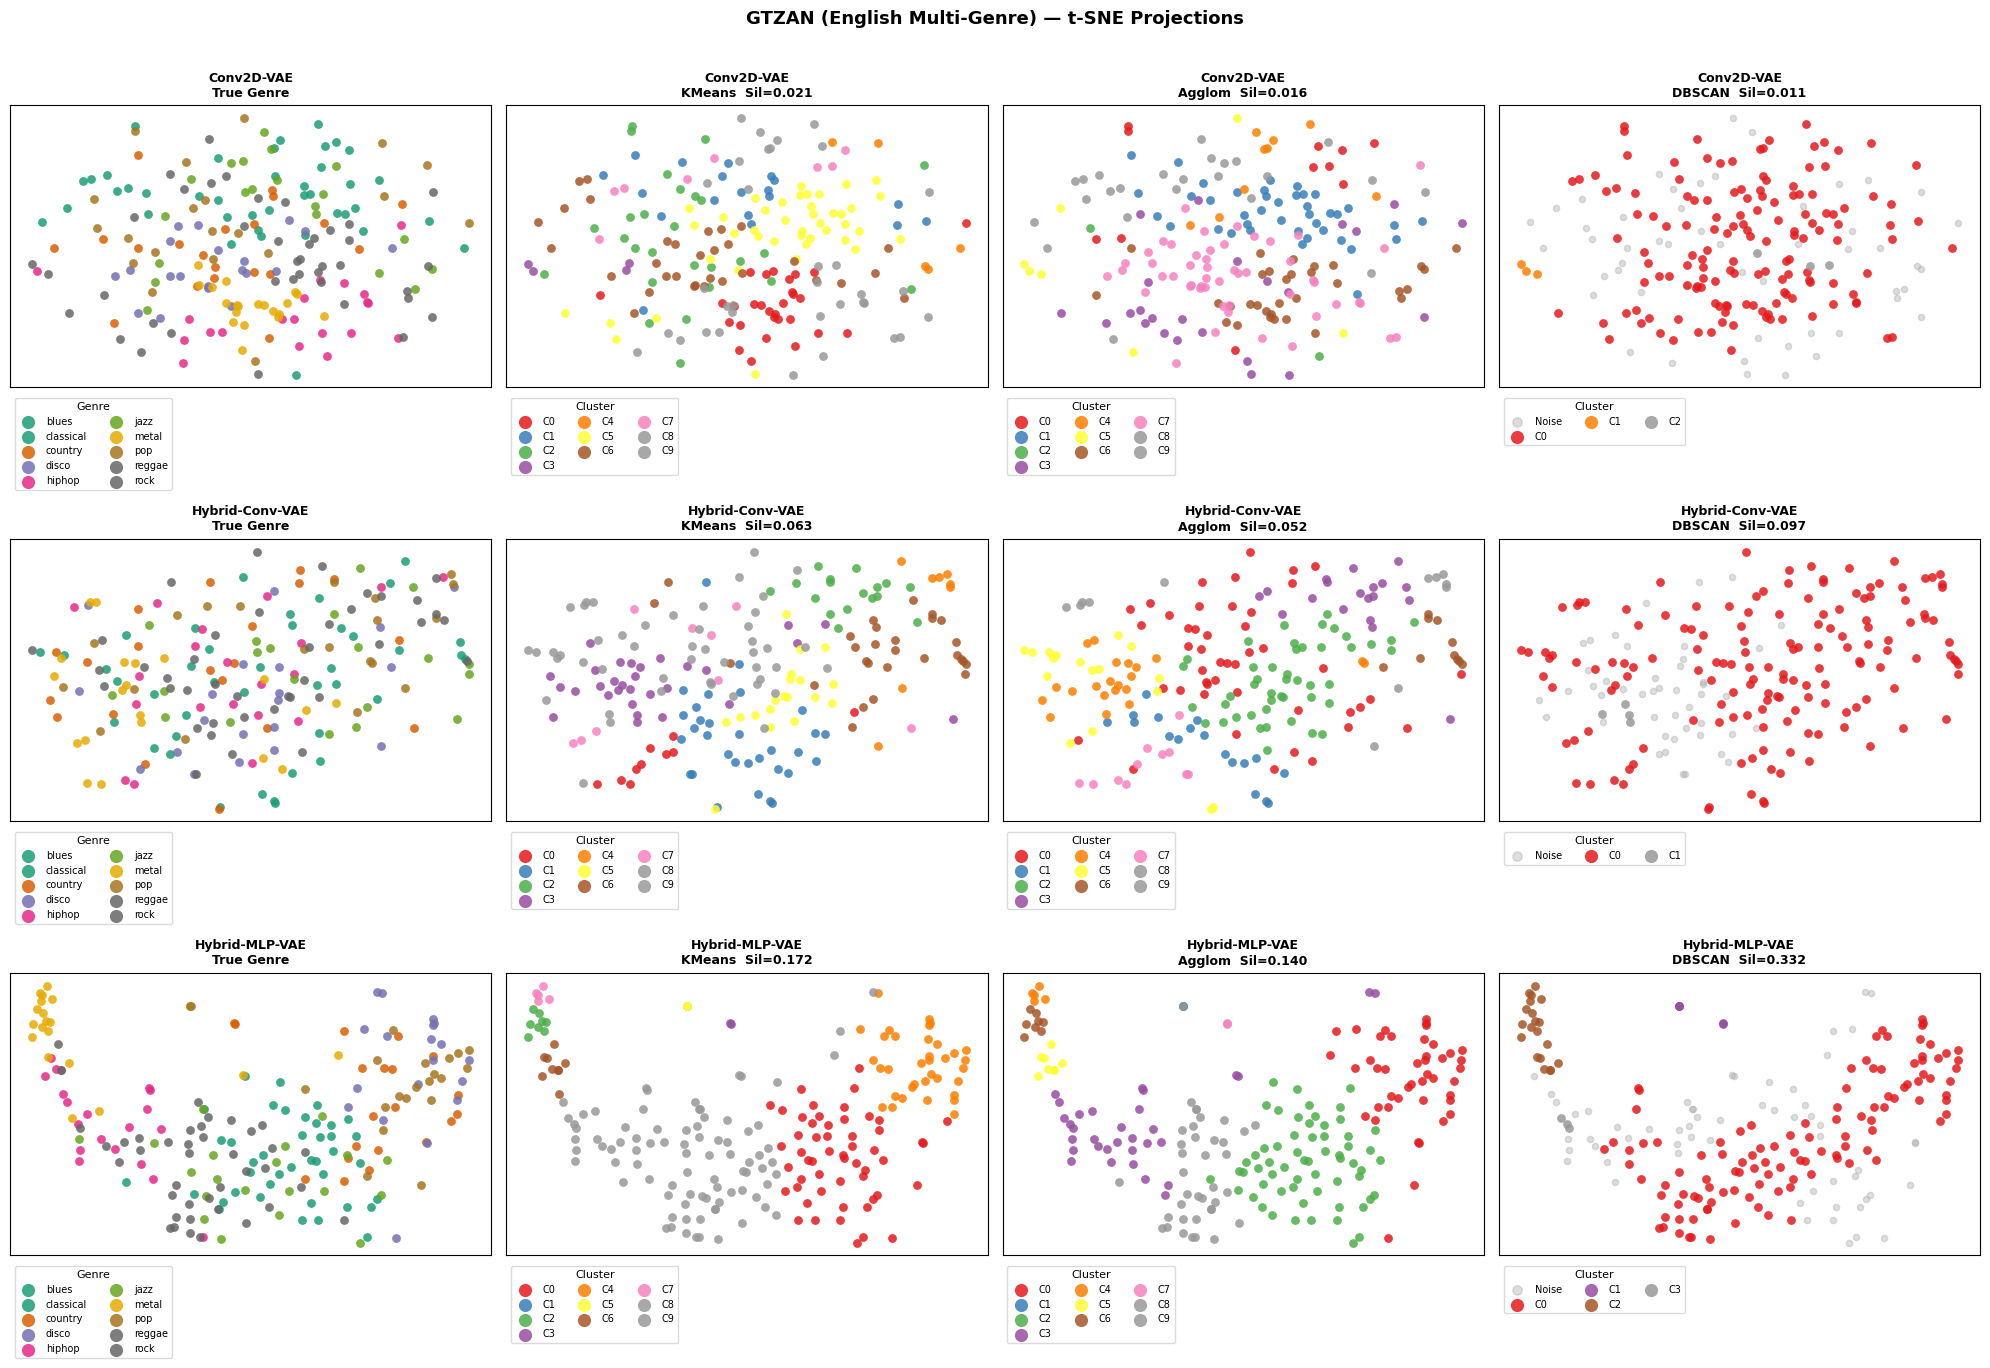

✅ Saved: /content/vae_medium_outputs/latent_gtzan_tsne.png


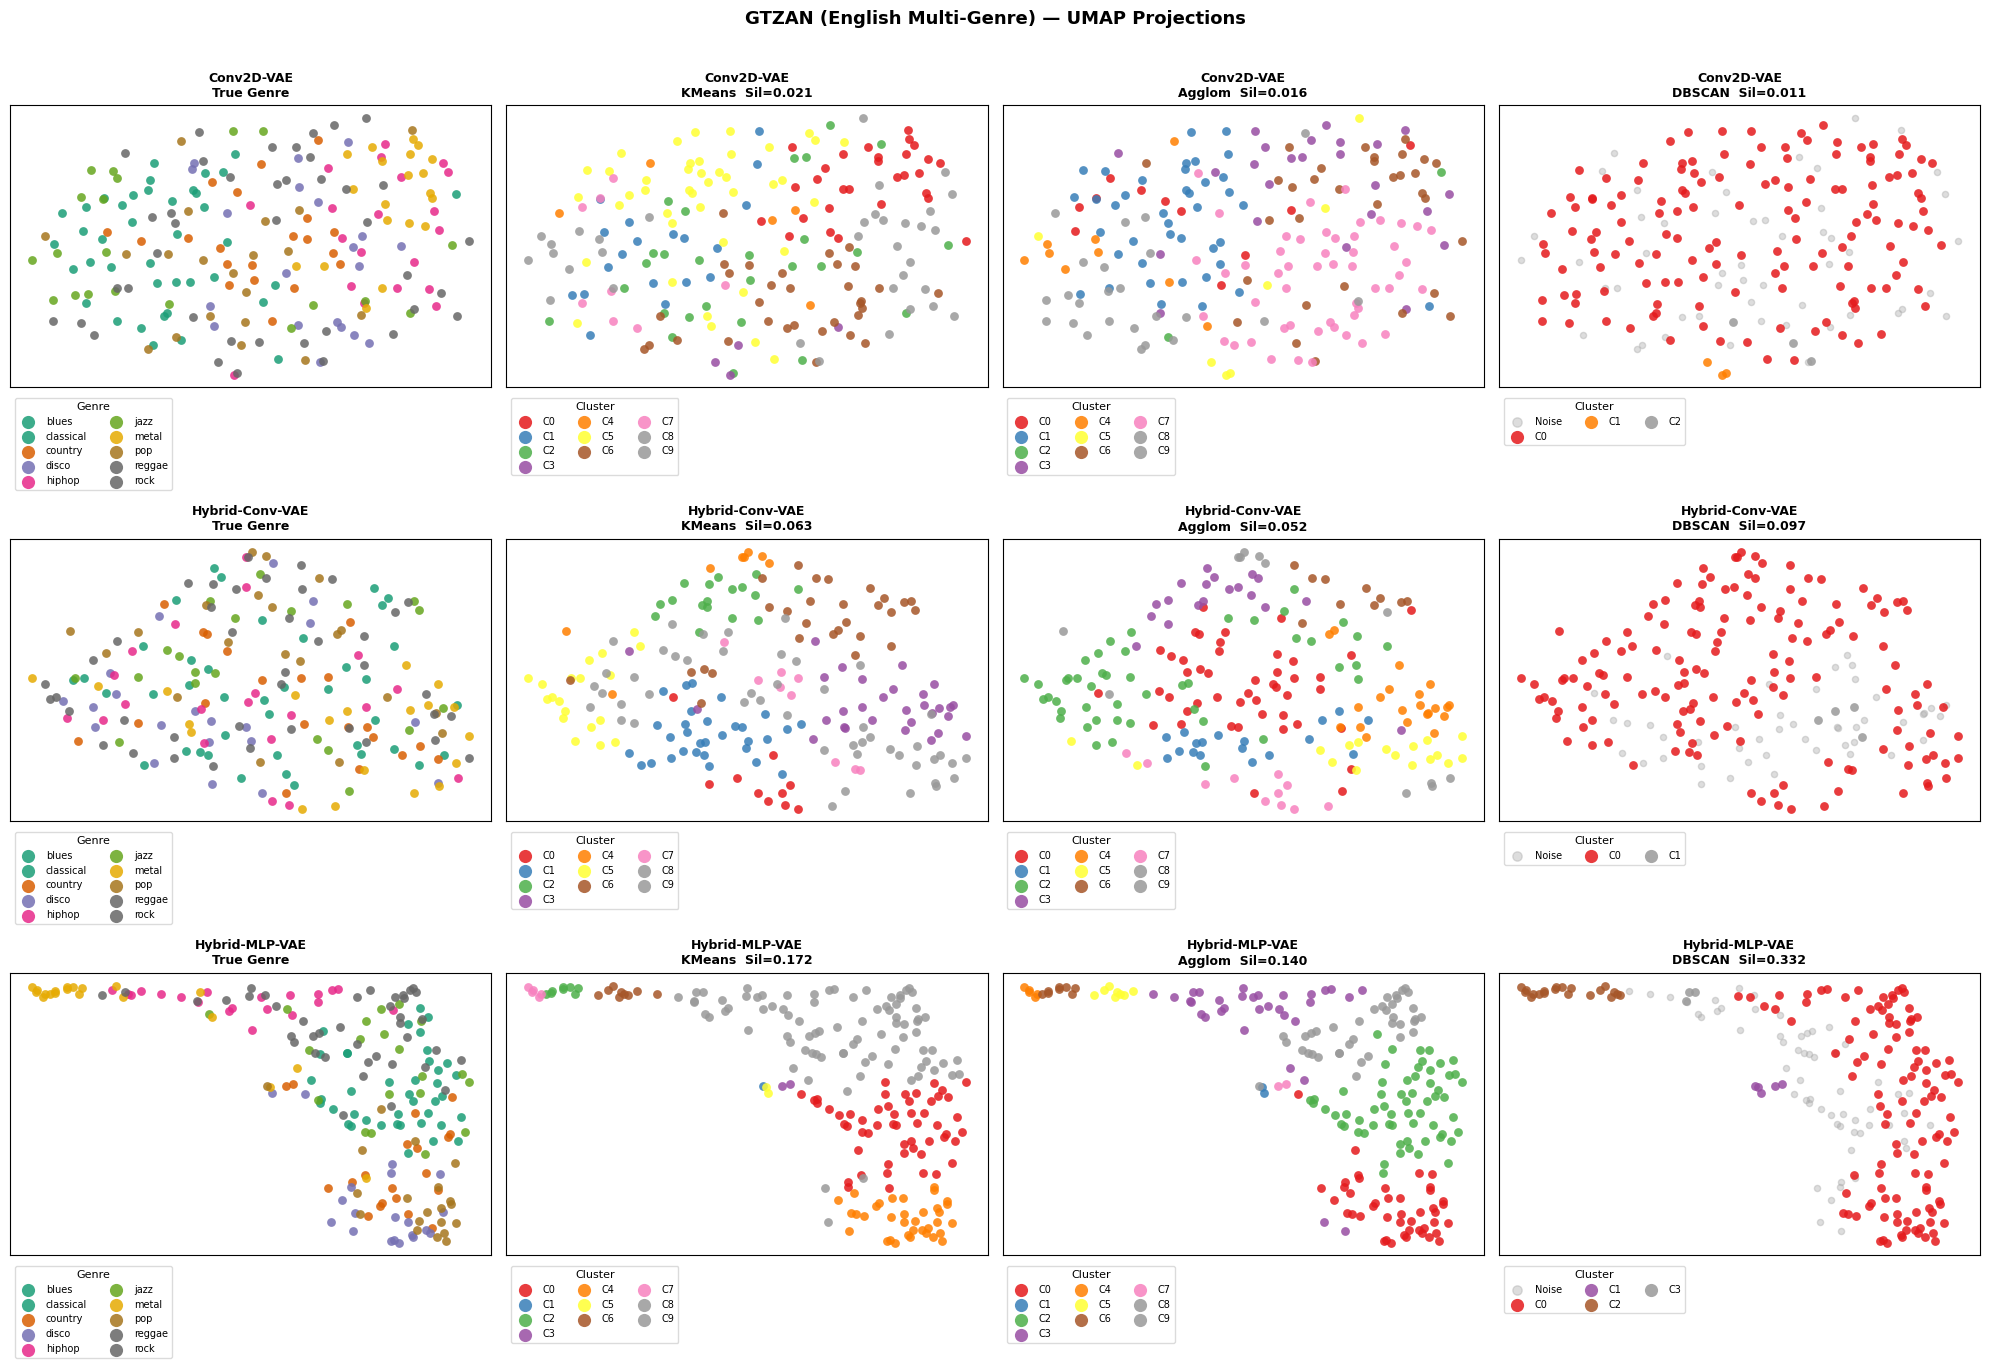

✅ Saved: /content/vae_medium_outputs/latent_gtzan_umap.png


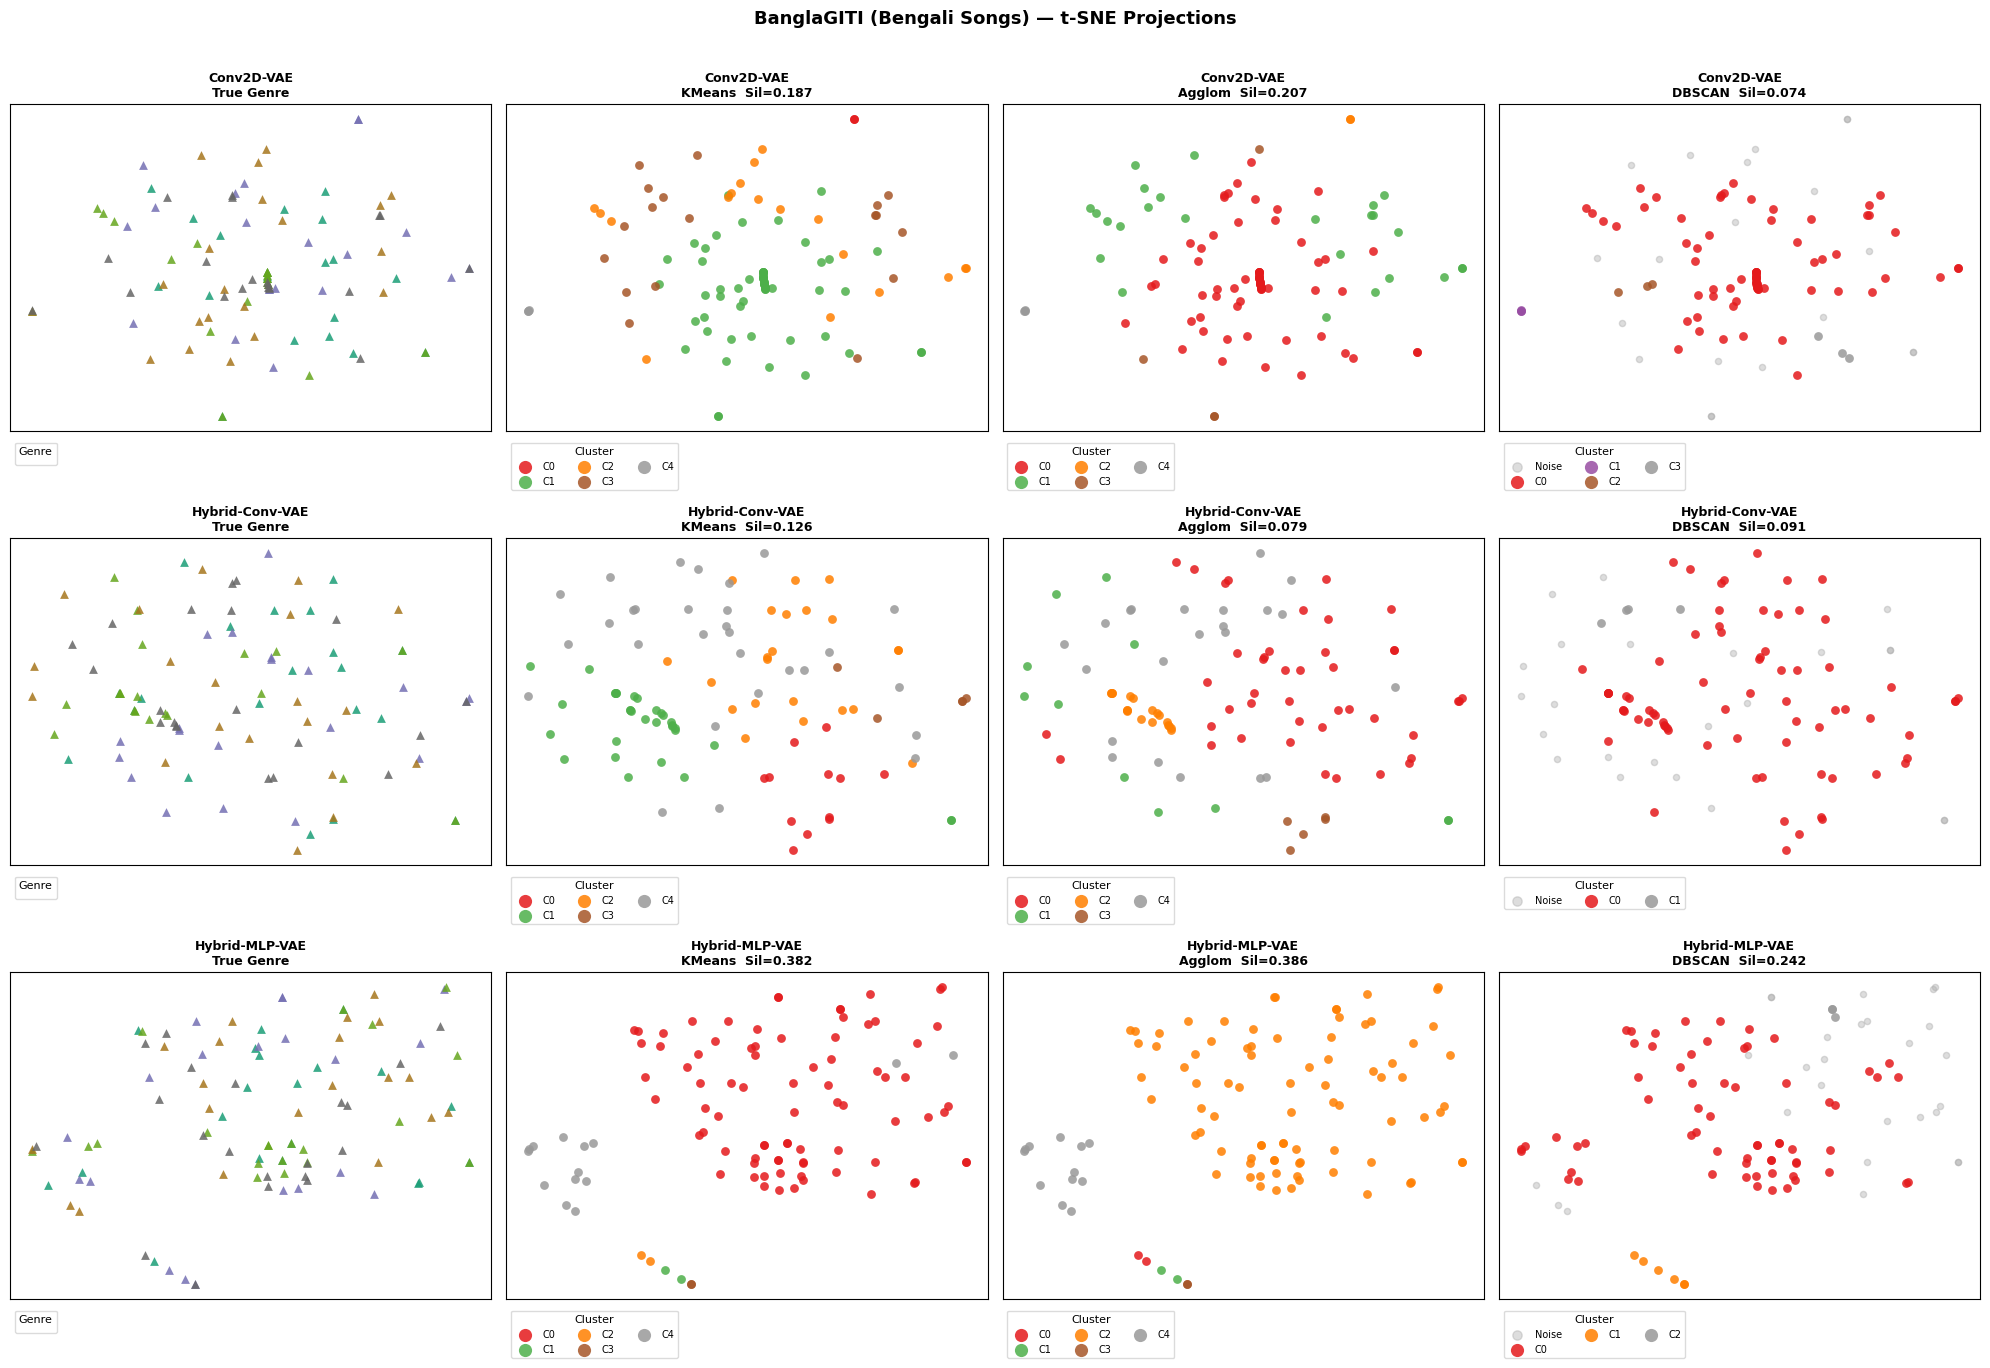

✅ Saved: /content/vae_medium_outputs/latent_banglagiti_tsne.png


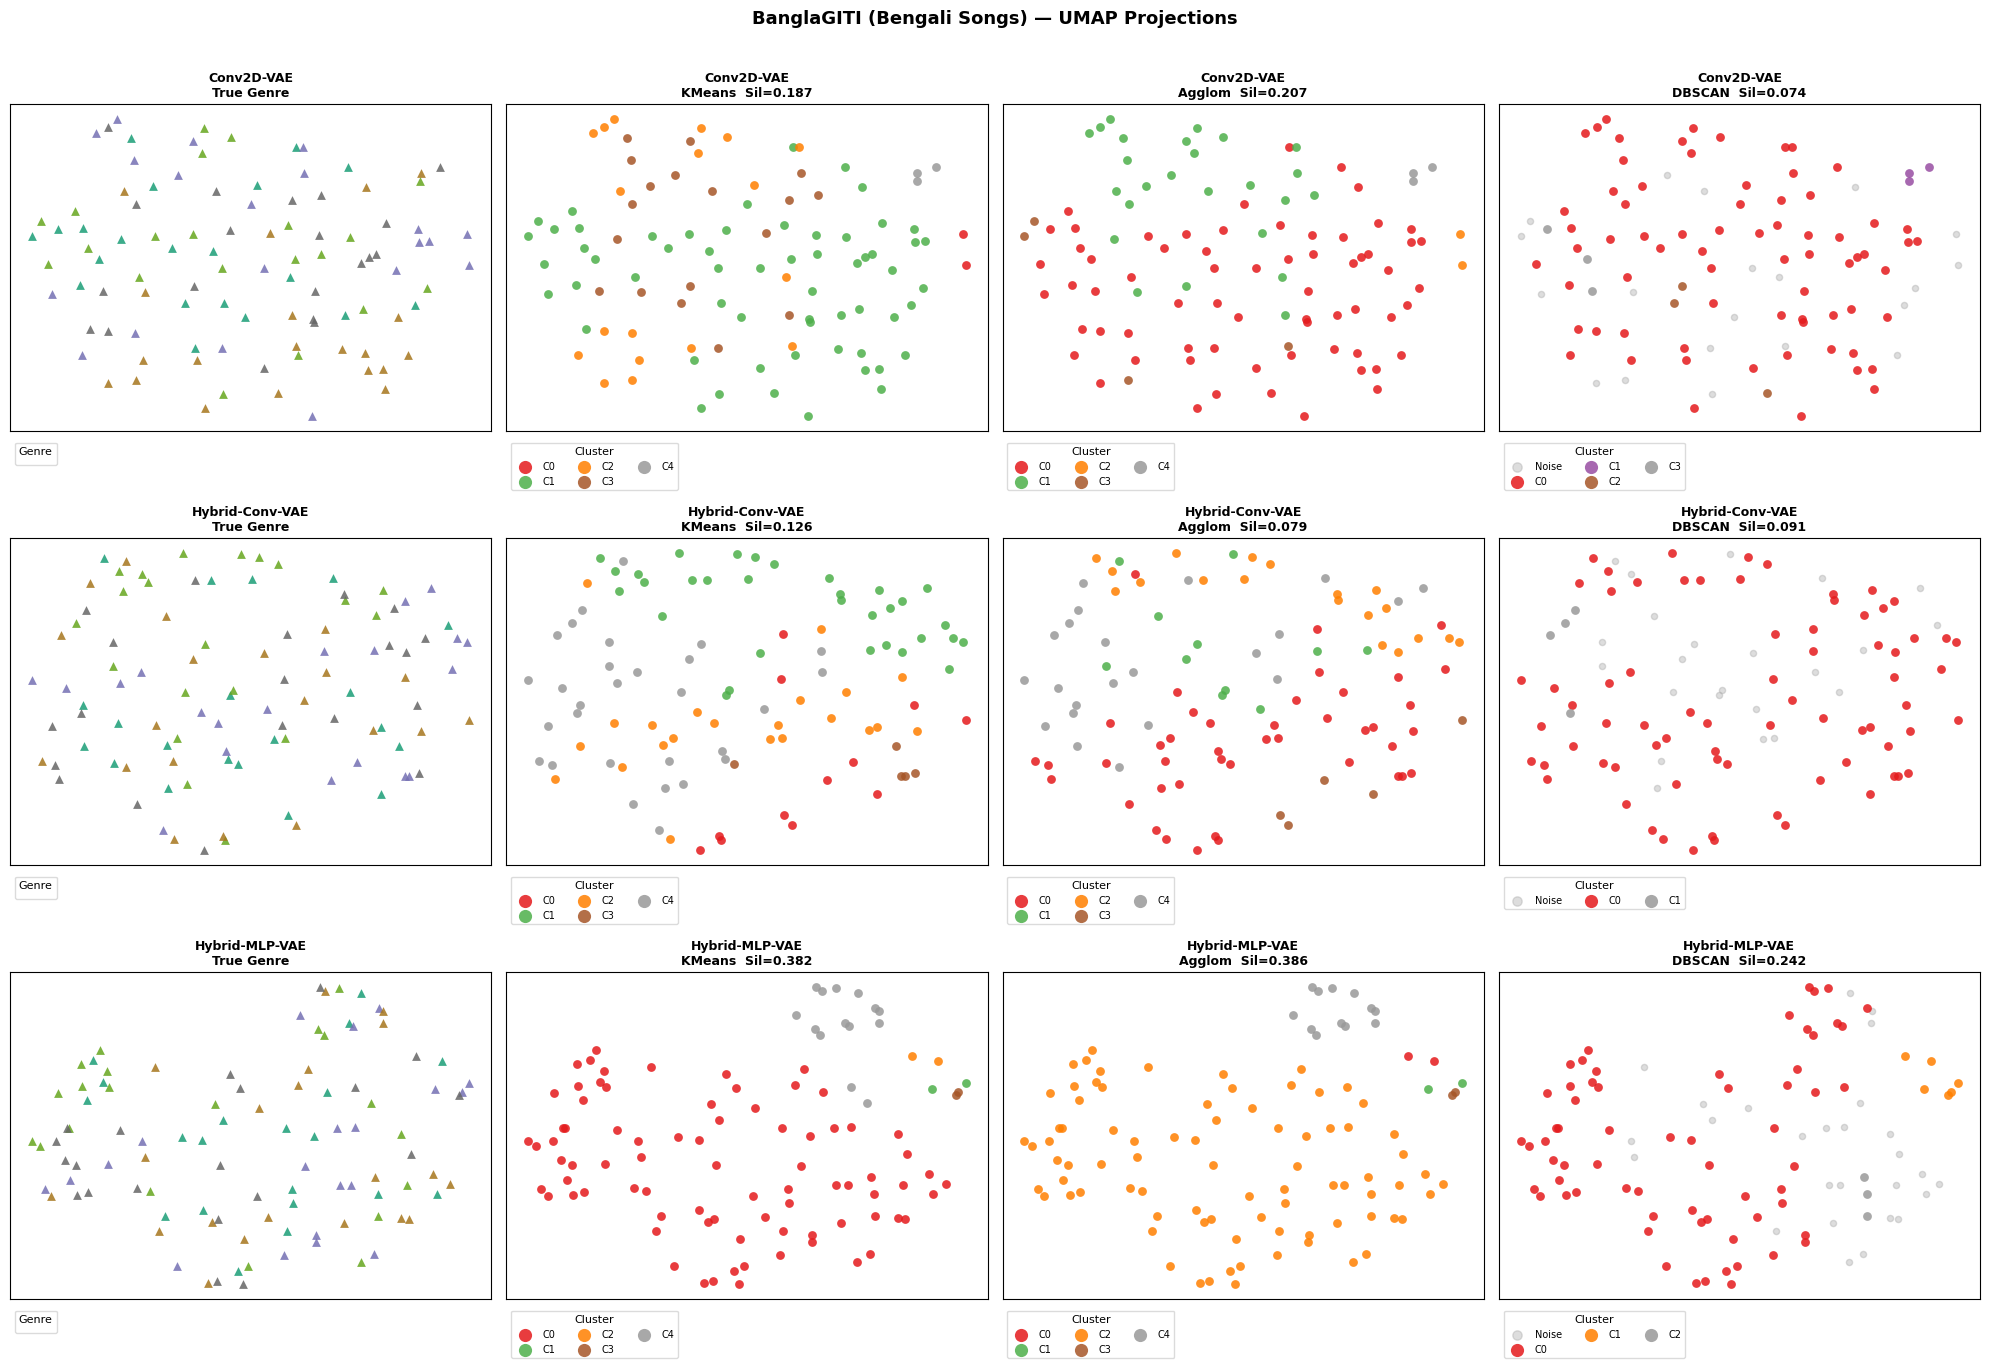

✅ Saved: /content/vae_medium_outputs/latent_banglagiti_umap.png


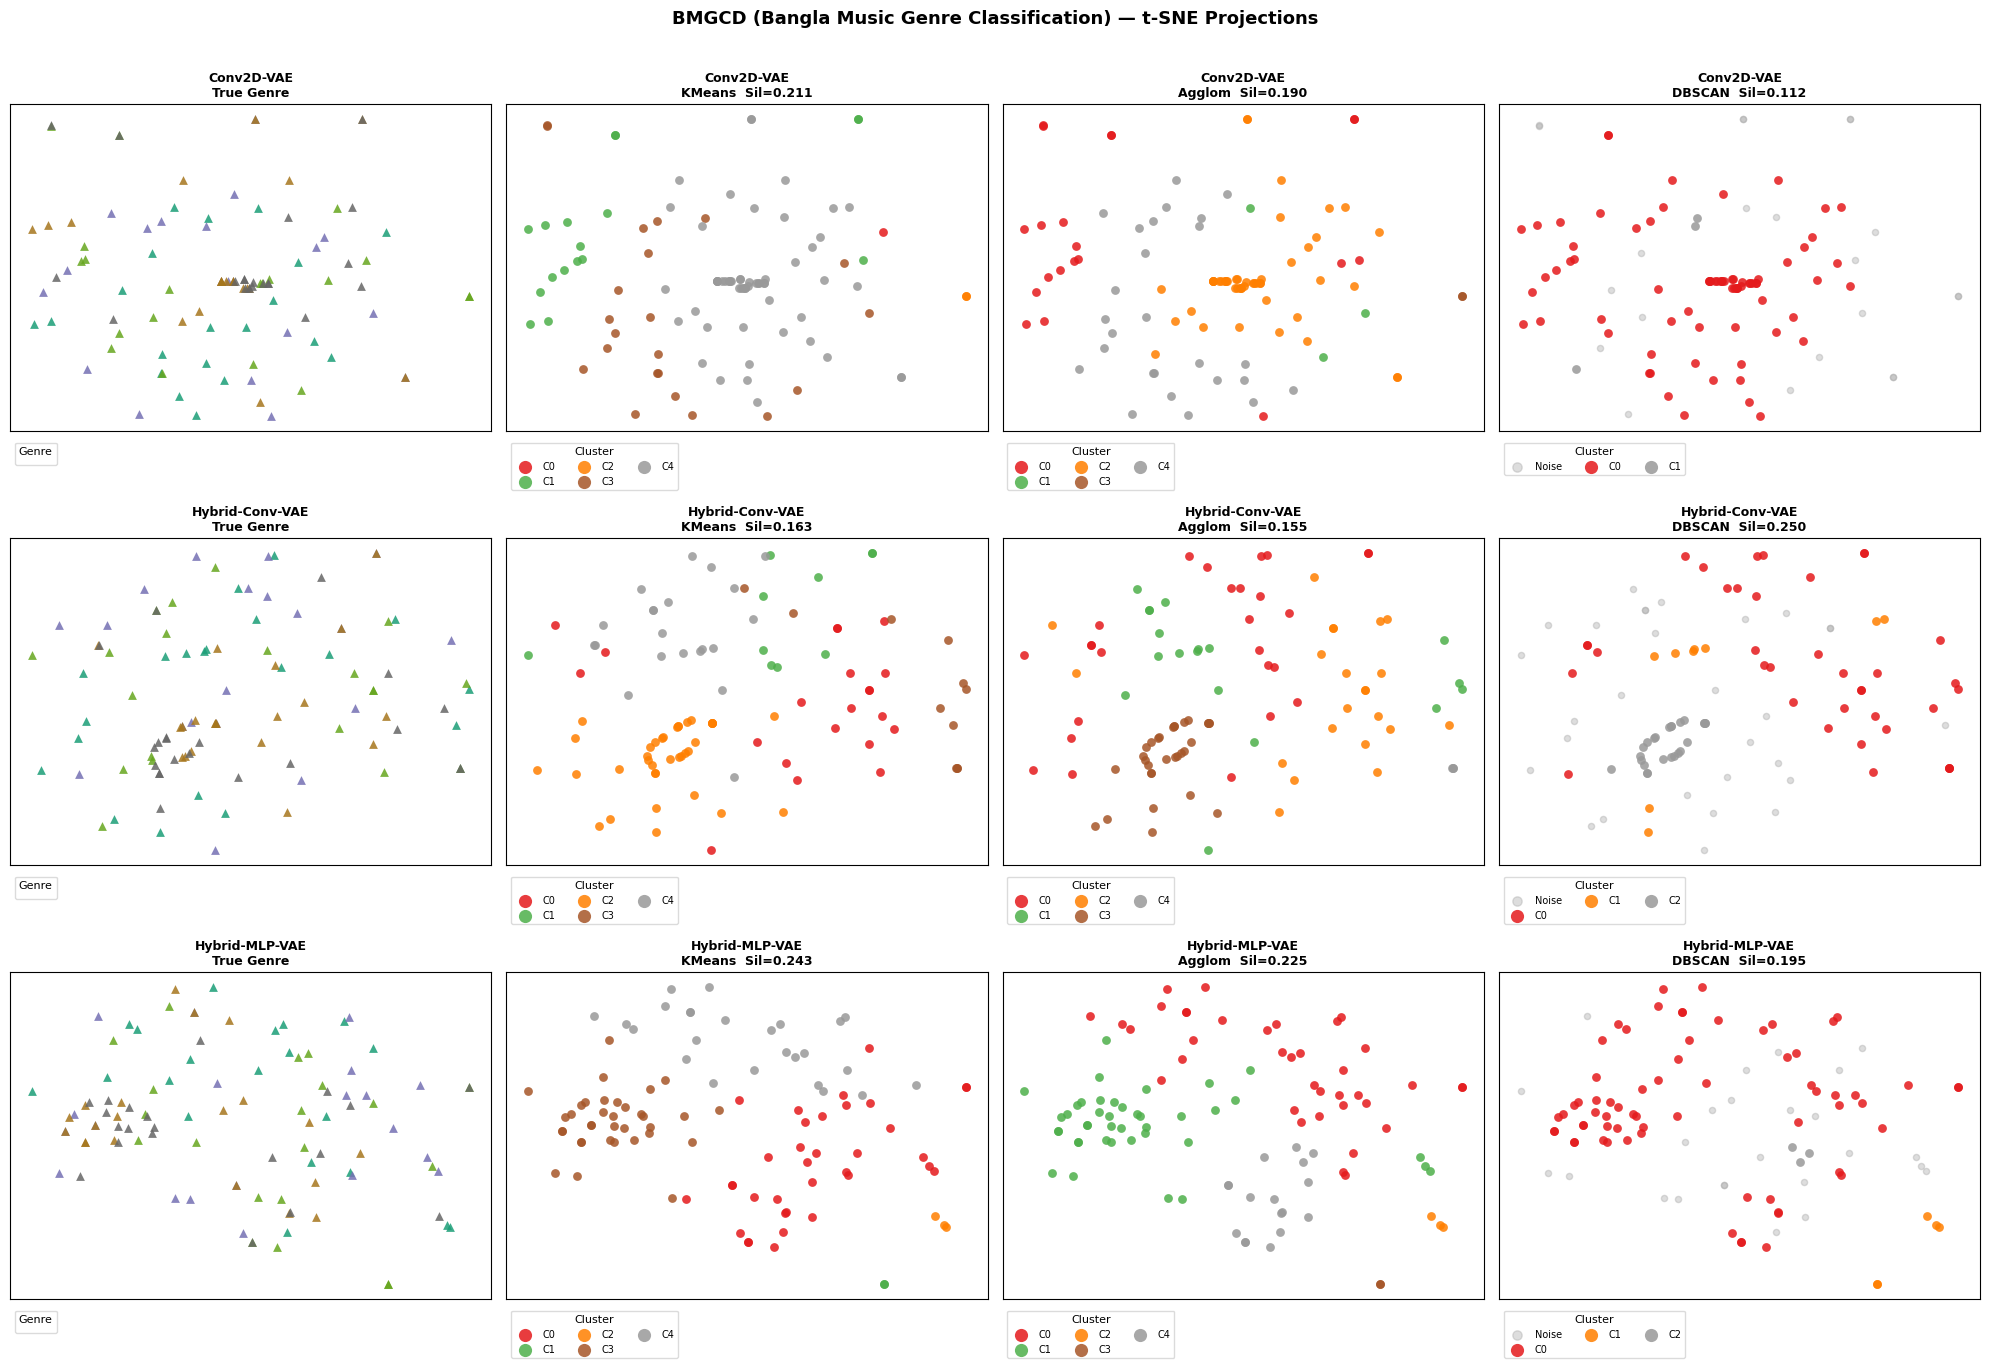

✅ Saved: /content/vae_medium_outputs/latent_bmgcd_tsne.png


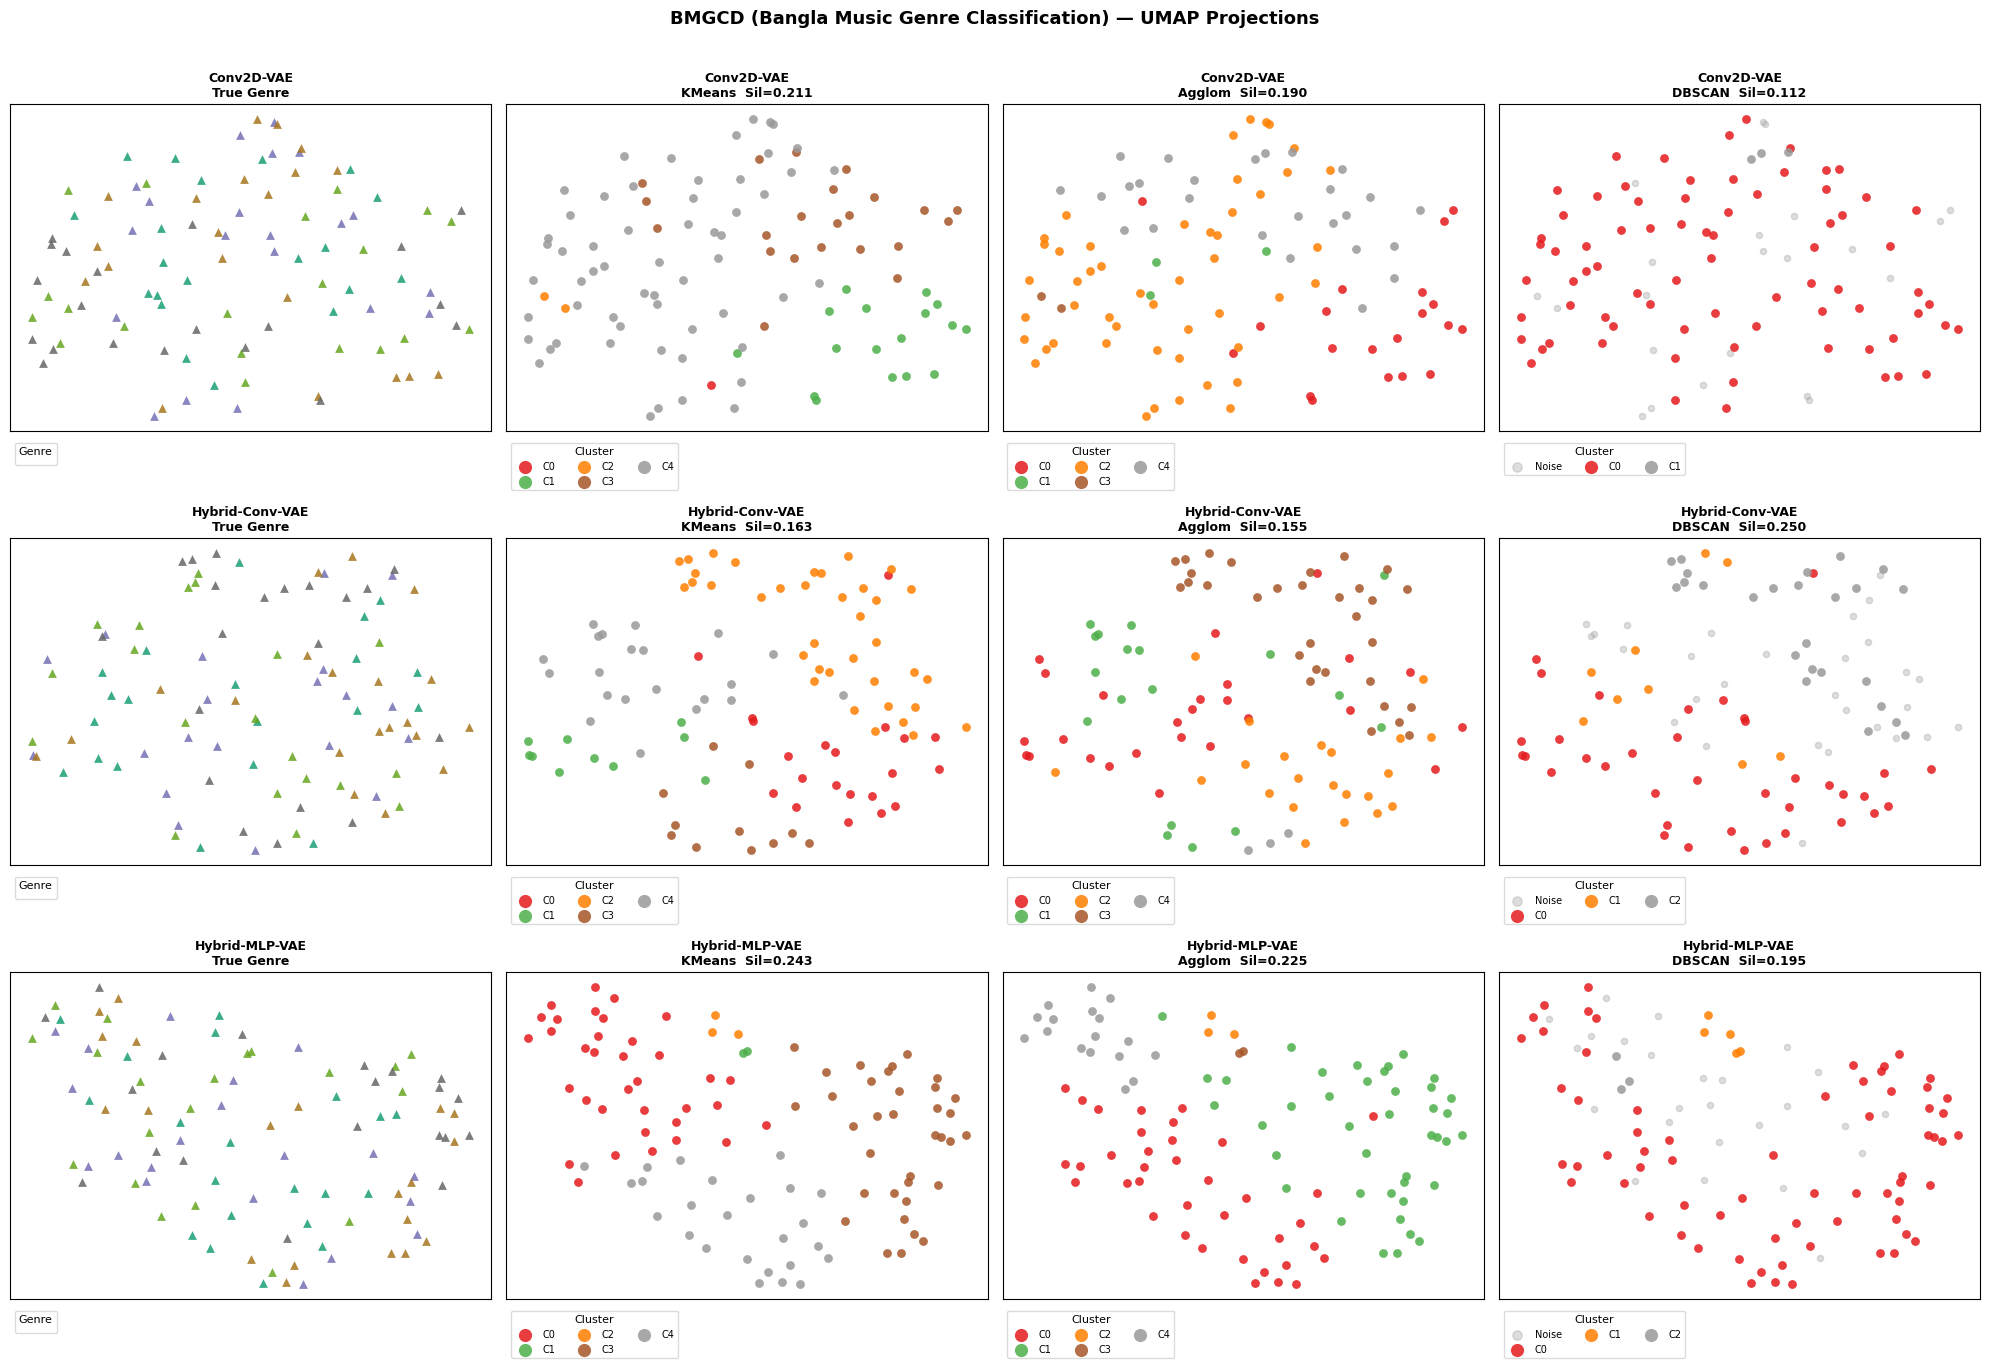

✅ Saved: /content/vae_medium_outputs/latent_bmgcd_umap.png


In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
MODELS_TO_PLOT = ['conv', 'hybrid', 'hybrid_mlp']  # removed mlp and pca
MODEL_LABELS_PLOT = {
    'conv':       'Conv2D-VAE',
    'hybrid':     'Hybrid-Conv-VAE',
    'hybrid_mlp': 'Hybrid-MLP-VAE',
}

DARK_PAL   = plt.cm.get_cmap('Dark2')   # dark, distinct genre colors
CLUST_PAL  = plt.cm.get_cmap('Set1')    # dark cluster colors

for key, res in all_results.items():
    n_class = res['n_class']

    for proj, pname in [('tsne', 't-SNE'), ('umap', 'UMAP')]:

        # ── Each model gets its own figure: 3 subplots (TrueGenre|KMeans|Agglom|DBSCAN)
        # ── 3 cols per row → one row per model
        n_models = len(MODELS_TO_PLOT)
        n_cols   = 4   # TrueGenre | KMeans | Agglomerative | DBSCAN
        fig, axes = plt.subplots(n_models, n_cols,
                                 figsize=(n_cols * 5, n_models * 4.5))
        fig.suptitle(f'{res["name"]} — {pname} Projections',
                     fontsize=13, fontweight='bold', y=1.01)

        for row, zkey in enumerate(MODELS_TO_PLOT):
            vis = res['vis'][zkey]
            cl  = res['cl'][zkey]
            Z2  = vis[proj]
            ml  = MODEL_LABELS_PLOT[zkey]

            # ── Col 0: True Genre ─────────────────────────────────────────────
            ax = axes[row, 0]
            for gi in range(n_class):
                mask  = res['y_true'] == gi
                color = DARK_PAL(gi / max(n_class - 1, 1))
                label = res['le'].classes_[gi]
                for lang, mk in LANG_MK.items():
                    lm = (res['lang_labels'] == lang) & mask
                    if lm.any():
                        ax.scatter(Z2[lm, 0], Z2[lm, 1],
                                   c=[color], marker=mk, s=40, alpha=0.85,
                                   linewidths=0, label=label if lang == list(LANG_MK.keys())[0] else '')
            ax.set_title(f'{ml}\nTrue Genre', fontsize=9, fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(alpha=0.2)
            ax.legend(title='Genre', fontsize=7, title_fontsize=8,
                      markerscale=1.5, bbox_to_anchor=(0, -0.02),
                      loc='upper left', ncol=2, framealpha=0.7)

            # ── Col 1: KMeans ─────────────────────────────────────────────────
            ax = axes[row, 1]
            labels_km = cl['KMeans']['labels']
            for ci in np.unique(labels_km):
                mask = labels_km == ci
                ax.scatter(Z2[mask, 0], Z2[mask, 1],
                           c=[CLUST_PAL(ci / max(labels_km.max(), 1))],
                           s=40, alpha=0.85, linewidths=0, label=f'C{ci}')
            ax.set_title(f'{ml}\nKMeans  Sil={cl["KMeans"]["sil"]:.3f}',
                         fontsize=9, fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(alpha=0.2)
            ax.legend(title='Cluster', fontsize=7, title_fontsize=8,
                      markerscale=1.5, bbox_to_anchor=(0, -0.02),
                      loc='upper left', ncol=3, framealpha=0.7)

            # ── Col 2: Agglomerative ──────────────────────────────────────────
            ax = axes[row, 2]
            labels_ag = cl['Agglomerative']['labels']
            for ci in np.unique(labels_ag):
                mask = labels_ag == ci
                ax.scatter(Z2[mask, 0], Z2[mask, 1],
                           c=[CLUST_PAL(ci / max(labels_ag.max(), 1))],
                           s=40, alpha=0.85, linewidths=0, label=f'C{ci}')
            ax.set_title(f'{ml}\nAgglom  Sil={cl["Agglomerative"]["sil"]:.3f}',
                         fontsize=9, fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(alpha=0.2)
            ax.legend(title='Cluster', fontsize=7, title_fontsize=8,
                      markerscale=1.5, bbox_to_anchor=(0, -0.02),
                      loc='upper left', ncol=3, framealpha=0.7)

            # ── Col 3: DBSCAN ─────────────────────────────────────────────────
            ax = axes[row, 3]
            labels_db = cl['DBSCAN']['labels']
            noise     = labels_db == -1
            ax.scatter(Z2[noise, 0], Z2[noise, 1],
                       c='#aaaaaa', s=20, alpha=0.4, label='Noise')
            for ci in np.unique(labels_db[~noise]):
                mask = labels_db == ci
                ax.scatter(Z2[mask, 0], Z2[mask, 1],
                           c=[CLUST_PAL(ci / max(labels_db.max(), 1))],
                           s=40, alpha=0.85, linewidths=0, label=f'C{ci}')
            db_sil = f"{cl['DBSCAN']['sil']:.3f}" if not np.isnan(cl['DBSCAN']['sil']) else 'N/A'
            ax.set_title(f'{ml}\nDBSCAN  Sil={db_sil}',
                         fontsize=9, fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(alpha=0.2)
            ax.legend(title='Cluster', fontsize=7, title_fontsize=8,
                      markerscale=1.5, bbox_to_anchor=(0, -0.02),
                      loc='upper left', ncol=3, framealpha=0.7)

        plt.tight_layout()
        fname = f'{OUTPUT_DIR}/latent_{key.lower()}_{proj}.png'
        plt.savefig(fname, dpi=130, bbox_inches='tight')
        plt.show()
        print(f'✅ Saved: {fname}')

## 📈 Step 14: Elbow Method — Optimal K Selection  *(NEW)*

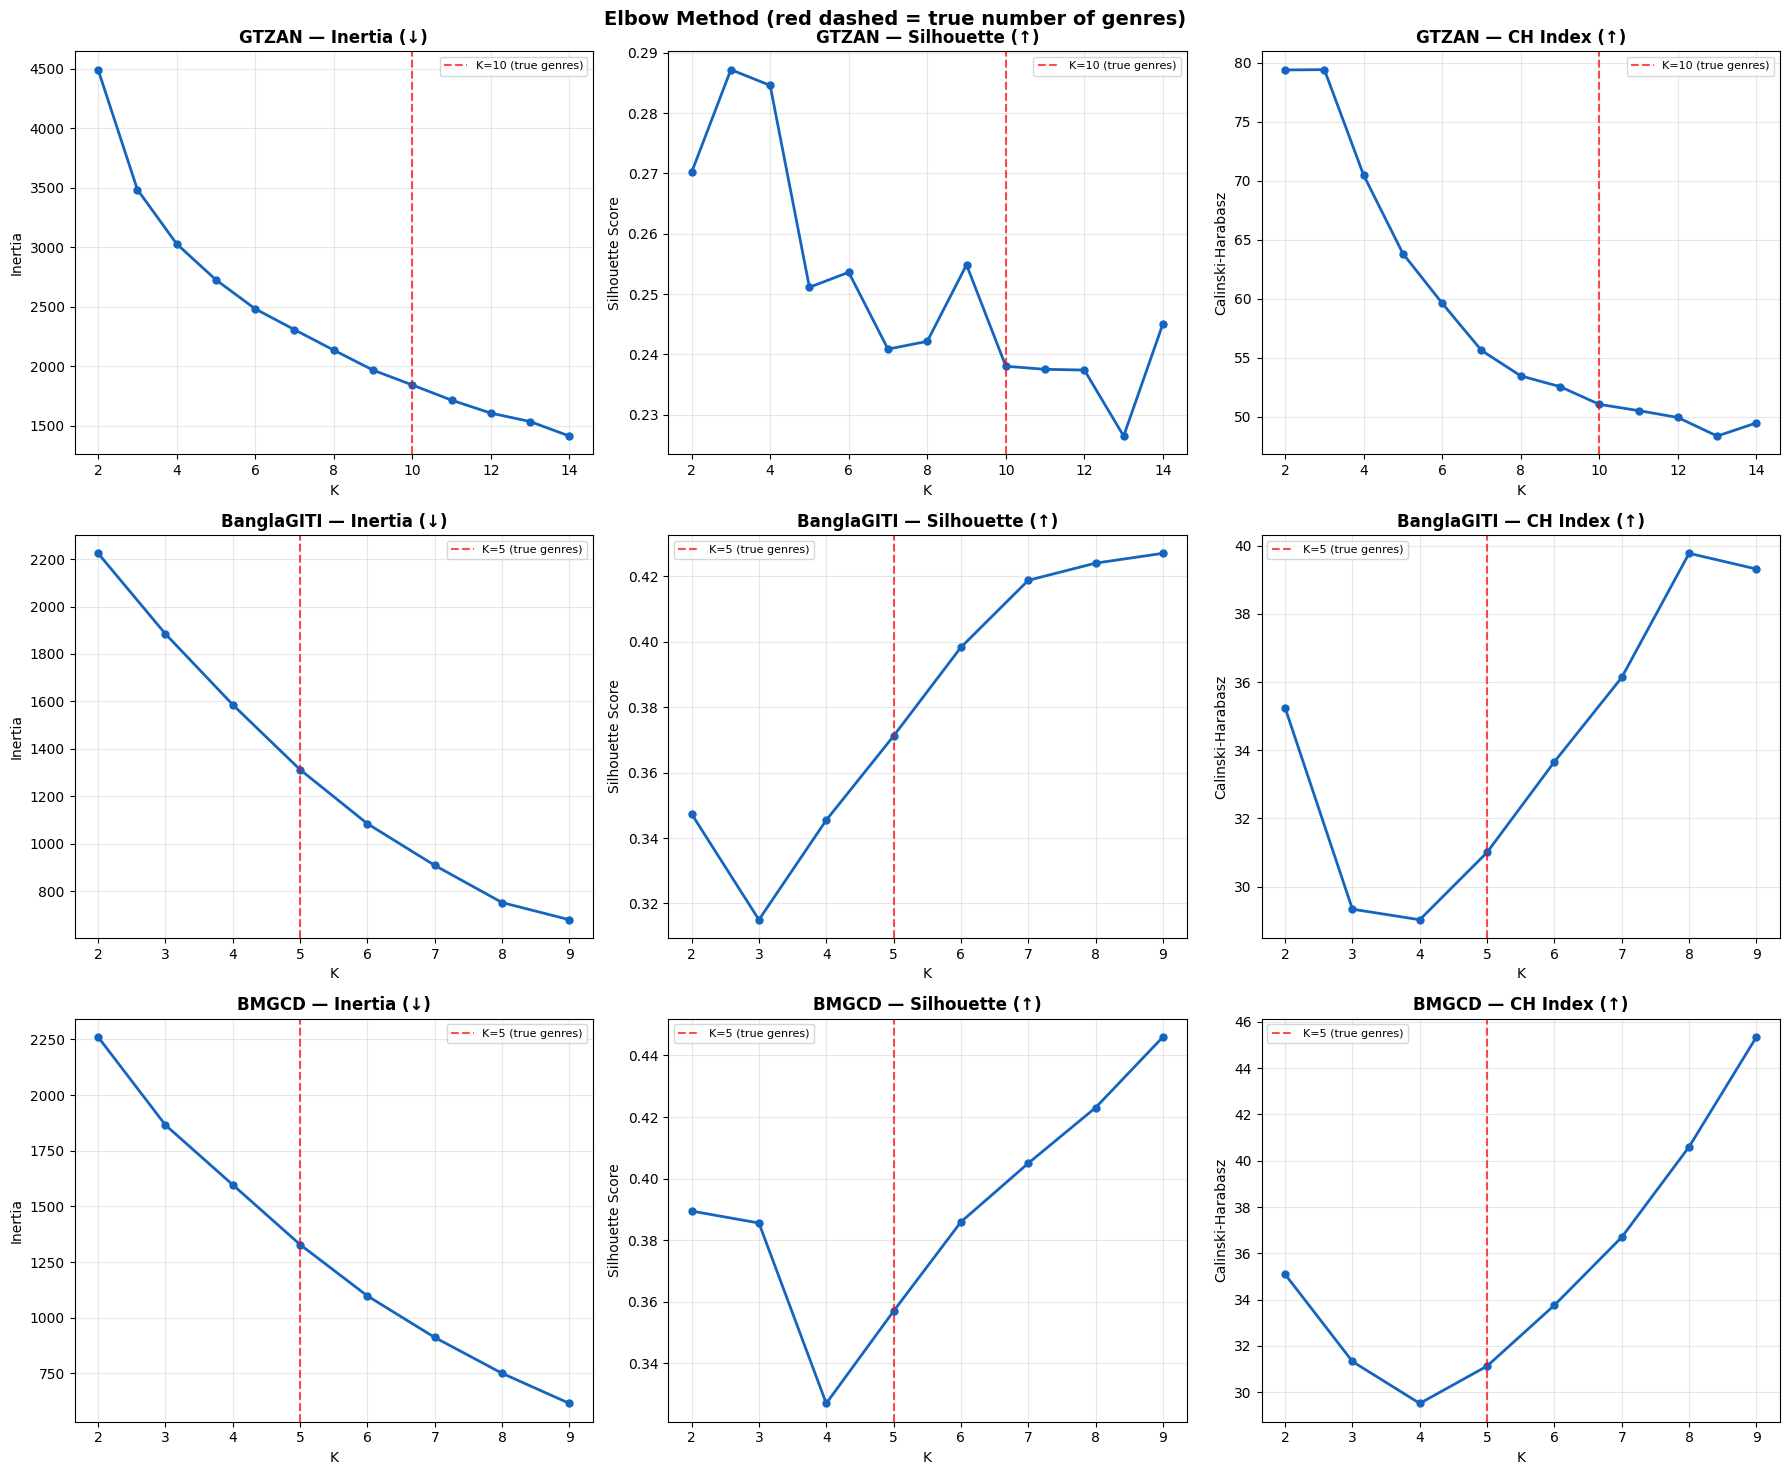

✅ Saved: elbow_plots.png


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Elbow Method (red dashed = true number of genres)', fontsize=14, fontweight='bold')
for row, (key, res) in enumerate(all_results.items()):
    elbow=res['elbow']; ks=elbow['k_range']
    for col, (vals, ylabel, title) in enumerate([
        (elbow['inertias'],  'Inertia',          'Inertia (↓)'),
        (elbow['sil_scores'],'Silhouette Score',  'Silhouette (↑)'),
        (elbow['ch_scores'], 'Calinski-Harabasz', 'CH Index (↑)'),
    ]):
        ax=axes[row,col]
        ax.plot(ks, vals, 'o-', color='#1565C0', linewidth=2, markersize=5)
        ax.axvline(res['n_class'], color='red', linestyle='--', alpha=0.7,
                   label=f'K={res["n_class"]} (true genres)')
        ax.set_xlabel('K'); ax.set_ylabel(ylabel)
        ax.set_title(f'{key} — {title}', fontweight='bold')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/elbow_plots.png', dpi=130, bbox_inches='tight')
plt.show(); print('✅ Saved: elbow_plots.png')

## 🔍 Step 15: DBSCAN Cluster Analysis

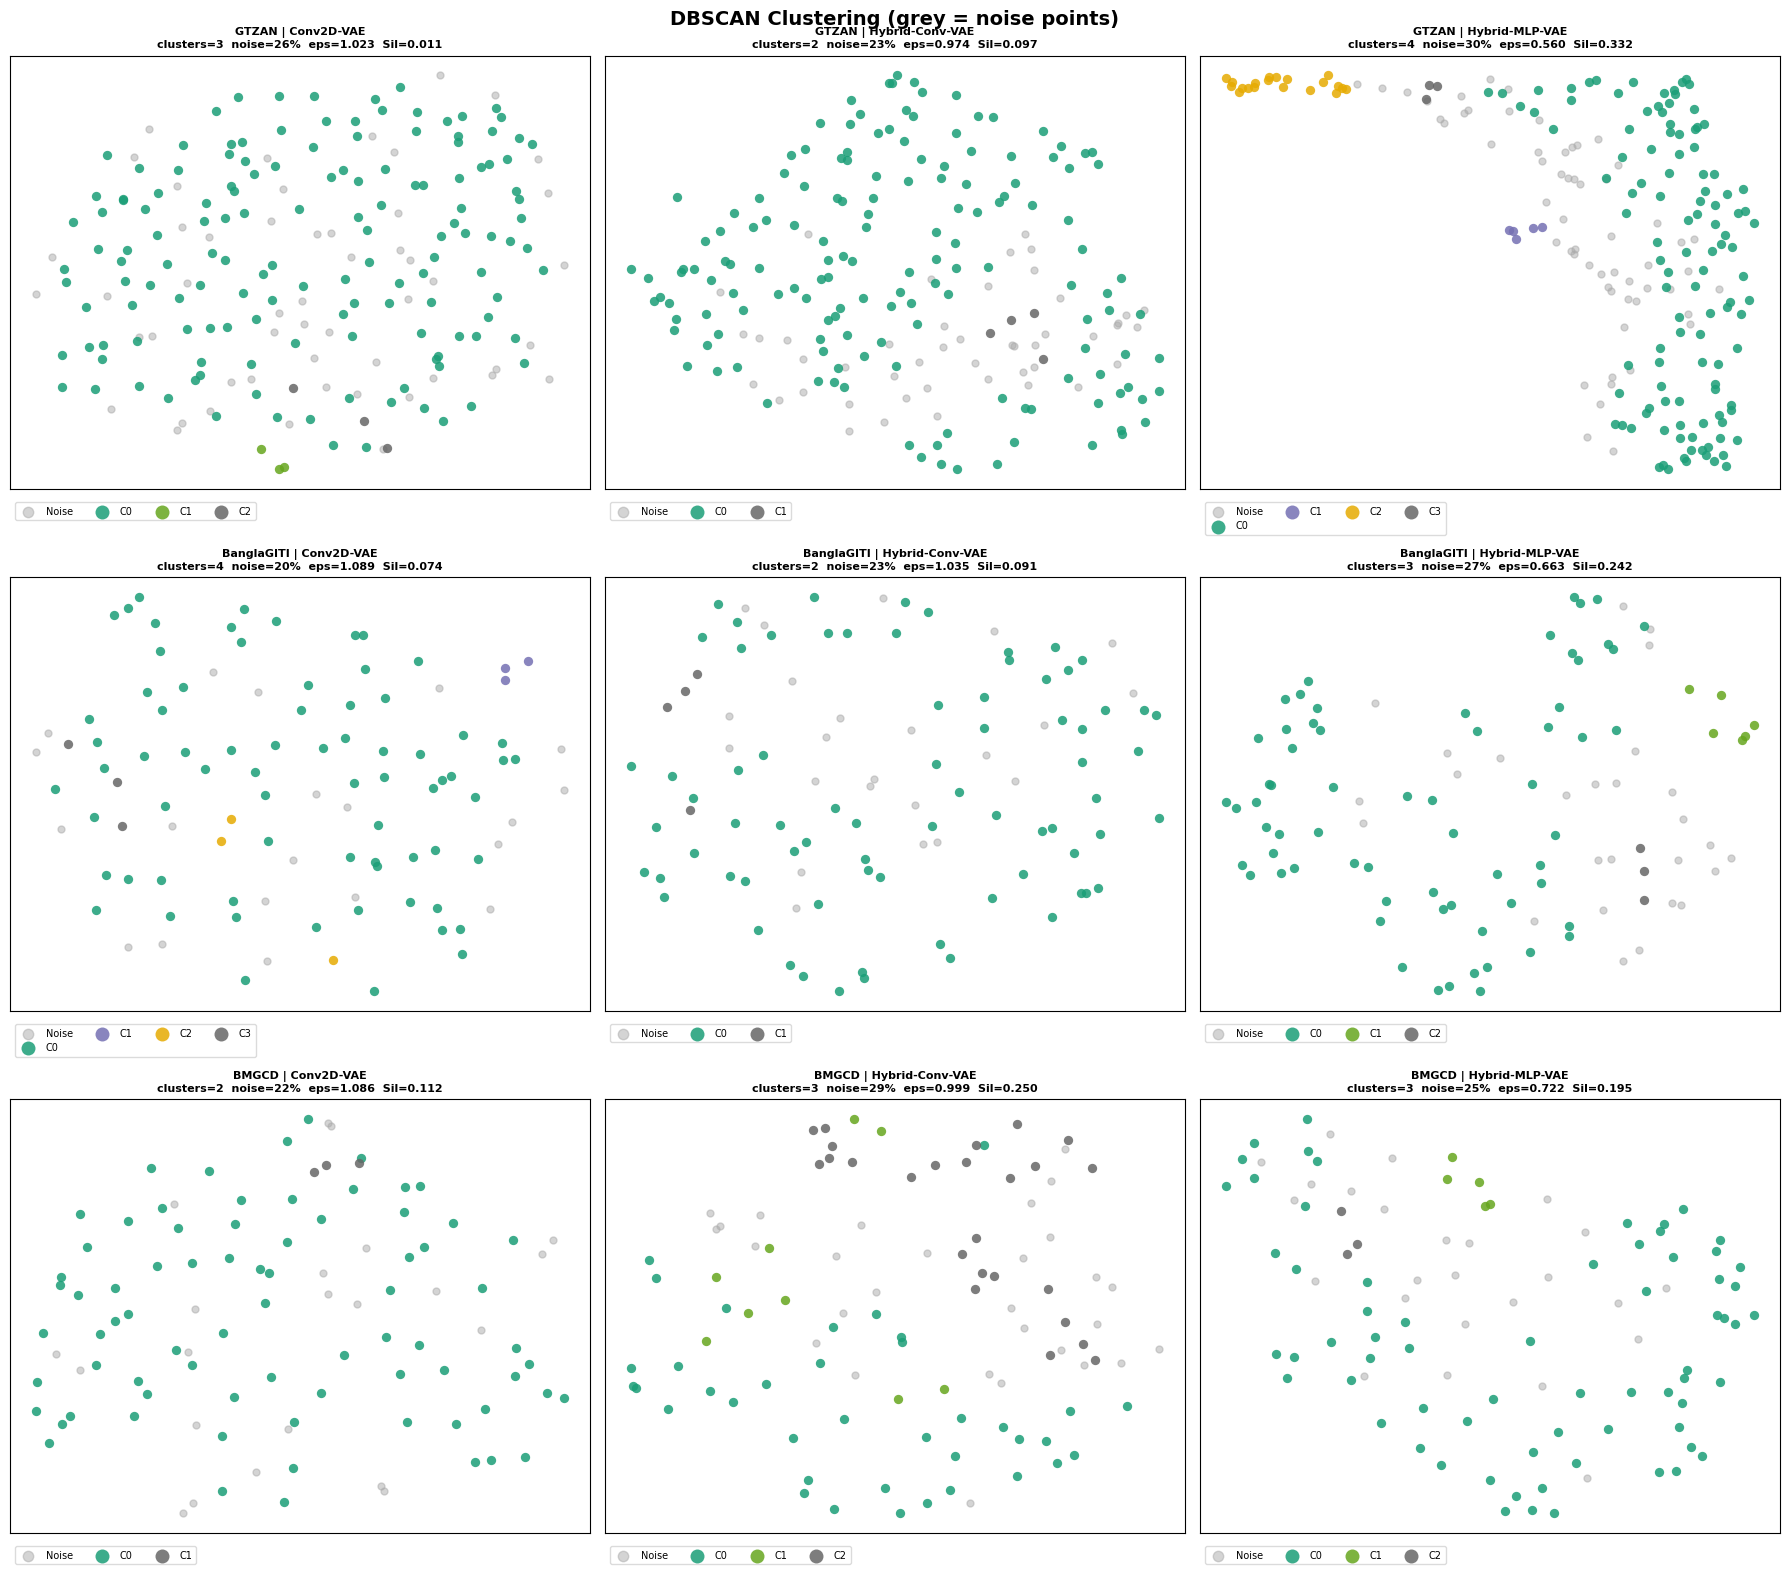

✅ Saved: dbscan_analysis.png


In [ ]:
MODELS_TO_PLOT = ['conv', 'hybrid', 'hybrid_mlp']

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle('DBSCAN Clustering (grey = noise points)', fontsize=14, fontweight='bold')

for row, (key, res) in enumerate(all_results.items()):
    for col, zkey in enumerate(MODELS_TO_PLOT):
        ax  = axes[row, col]
        Z2  = res['vis'][zkey]['umap']
        r   = res['cl'][zkey]['DBSCAN']
        lbls = r['labels']
        noise = lbls == -1

        # noise points
        ax.scatter(Z2[noise, 0], Z2[noise, 1],
                   c='#aaaaaa', s=25, alpha=0.5, label='Noise')

        # cluster points
        unique_clusters = np.unique(lbls[~noise]) if (~noise).any() else []
        for ci in unique_clusters:
            mask = lbls == ci
            color = plt.cm.Dark2(ci / max(len(unique_clusters) - 1, 1))
            ax.scatter(Z2[mask, 0], Z2[mask, 1],
                       c=[color], s=45, alpha=0.85,
                       linewidths=0, label=f'C{ci}')

        # title
        t = f'{key} | {MODEL_LABELS[zkey]}\n'
        t += f'clusters={r["n_found"]}  noise={r["noise_pct"]:.0f}%  eps={r["eps"]:.3f}'
        if not np.isnan(r['sil']):
            t += f'  Sil={r["sil"]:.3f}'
        ax.set_title(t, fontsize=8, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(alpha=0.2)
        ax.legend(fontsize=7, markerscale=1.5,
                  bbox_to_anchor=(0, -0.02), loc='upper left',
                  ncol=4, framealpha=0.7)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/dbscan_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved: dbscan_analysis.png')

## 🔬 Step 16: Cluster Composition Heatmap  *(NEW)*

**Genre % within each K-Means cluster.** Pure cluster = one genre dominates.

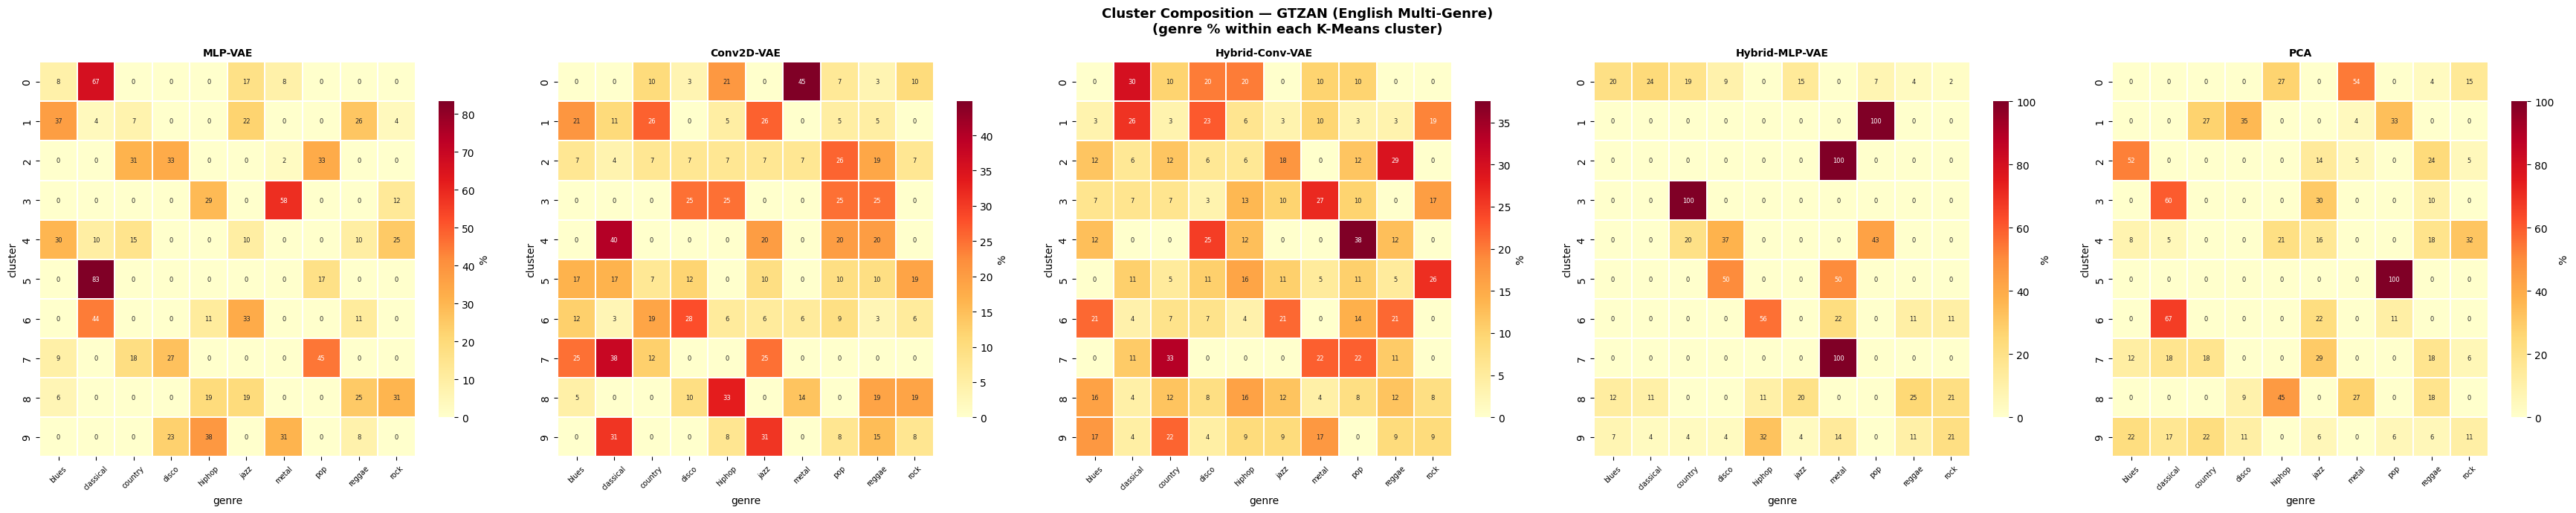

✅ Saved: cluster_composition_gtzan.png


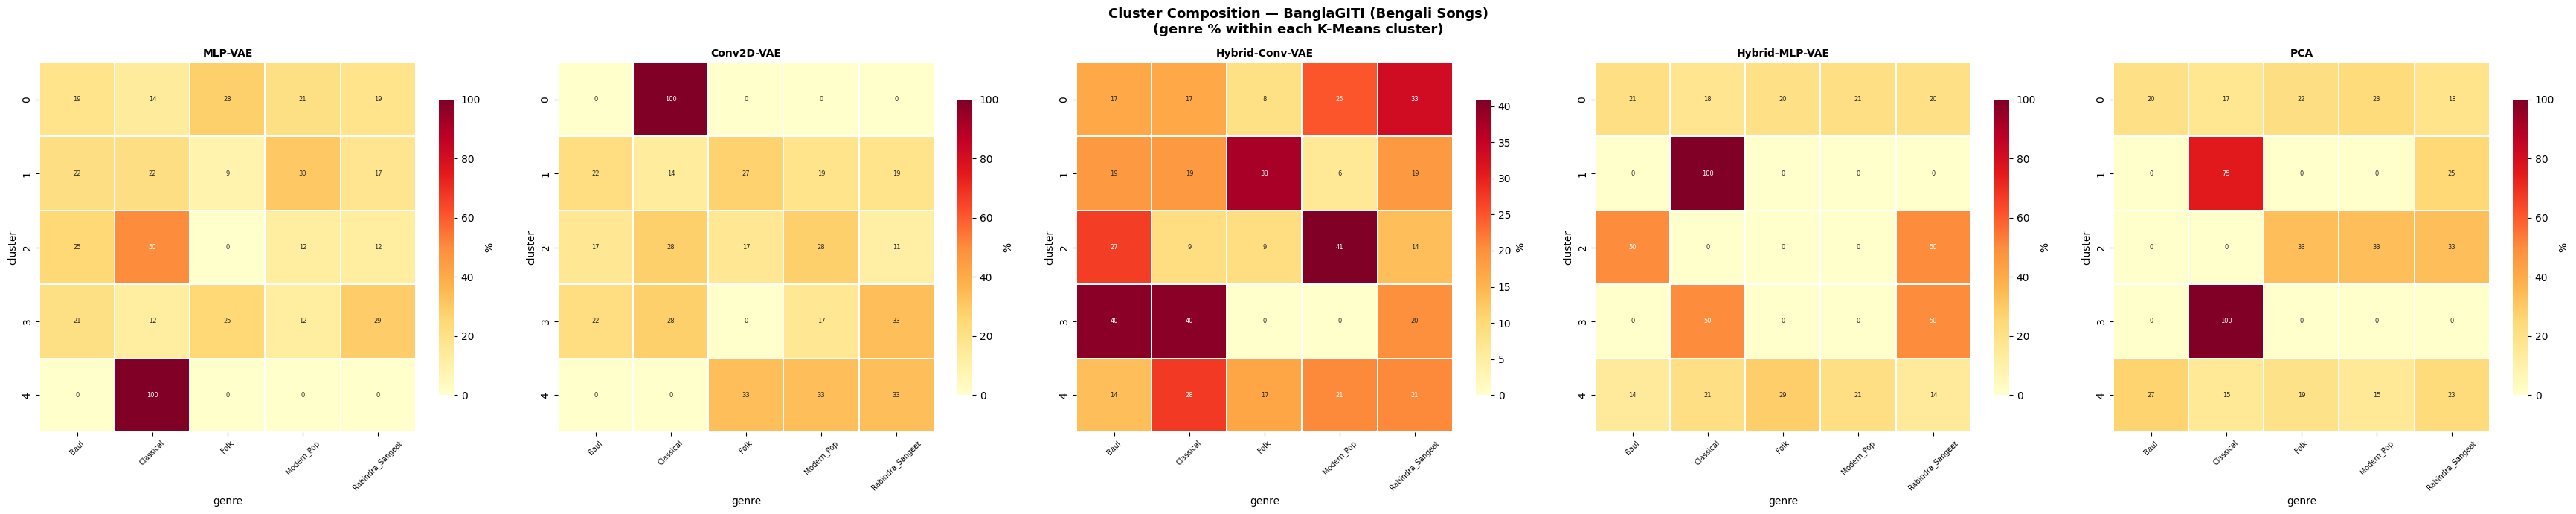

✅ Saved: cluster_composition_banglagiti.png


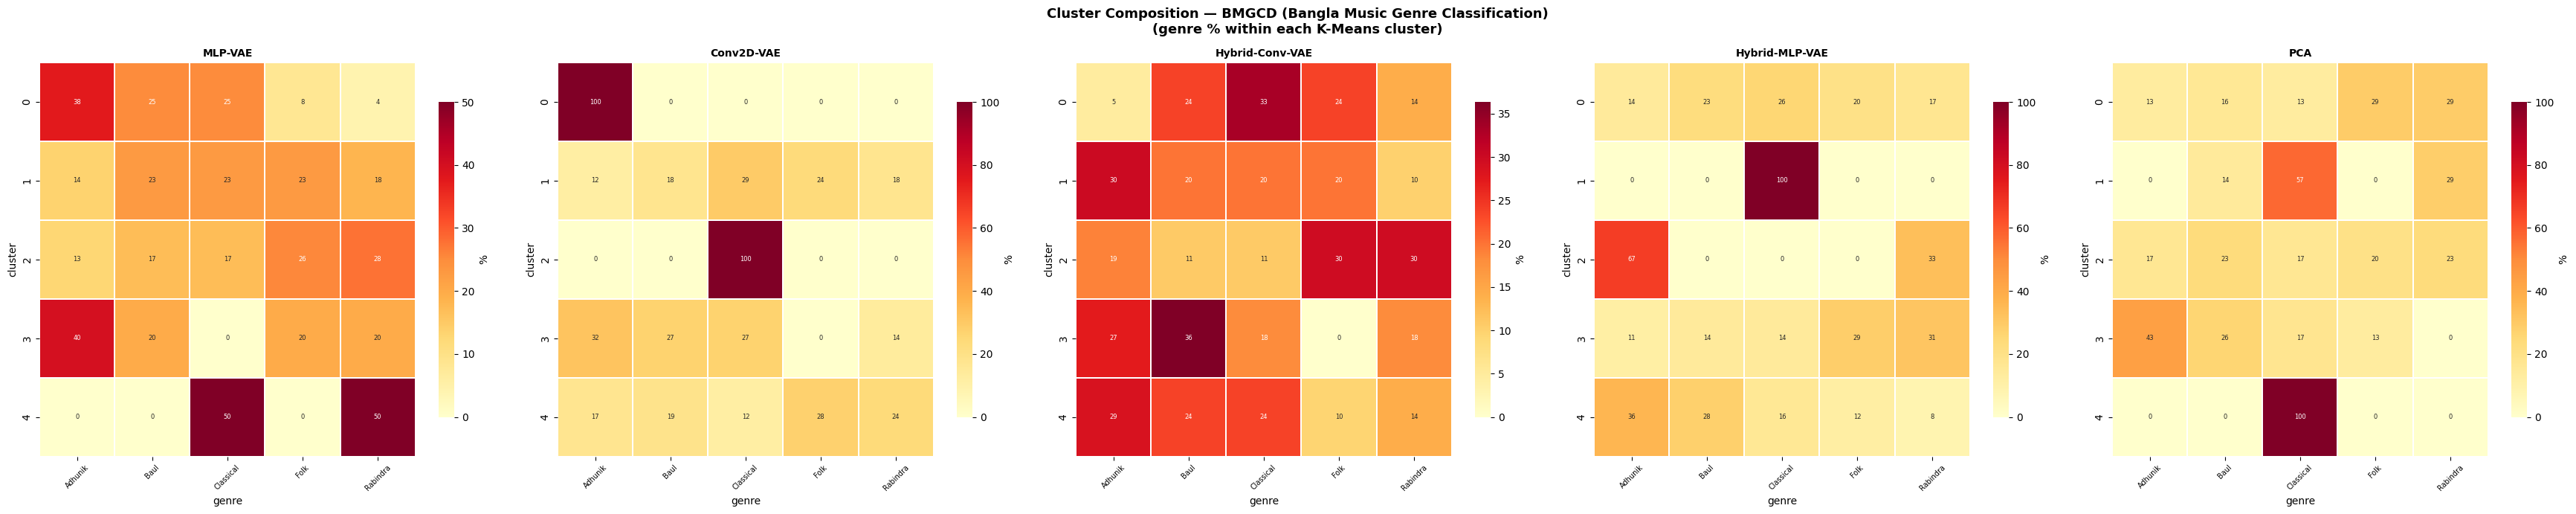

✅ Saved: cluster_composition_bmgcd.png


In [ ]:


for key, res in all_results.items():
    fig, axes = plt.subplots(1, 5, figsize=(35, 7))  # 4→5 cols, width বাড়াও
    fig.suptitle(f'Cluster Composition — {res["name"]}\n(genre % within each K-Means cluster)',
                 fontsize=13, fontweight='bold')
    for ax, zkey in zip(axes, ['mlp','conv','hybrid','hybrid_mlp','pca']):  # hybrid_mlp যোগ
        df = pd.DataFrame({'cluster':res['cl'][zkey]['KMeans']['labels'], 'genre':res['y_labels']})
        ct = pd.crosstab(df['cluster'], df['genre'])
        ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
        sns.heatmap(ct_pct, ax=ax, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.3,
                    cbar_kws={'label':'%','shrink':0.8}, annot_kws={'size':6})
        ax.set_title(MODEL_LABELS[zkey], fontweight='bold', fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/cluster_composition_{key.lower()}.png', dpi=130, bbox_inches='tight')
    plt.show(); print(f'✅ Saved: cluster_composition_{key.lower()}.png')

## 🇧🇩 Step 17: English vs Bangla Language Separation  *(NEW)*

Circle (●) = English  ·  Triangle (▲) = Bangla

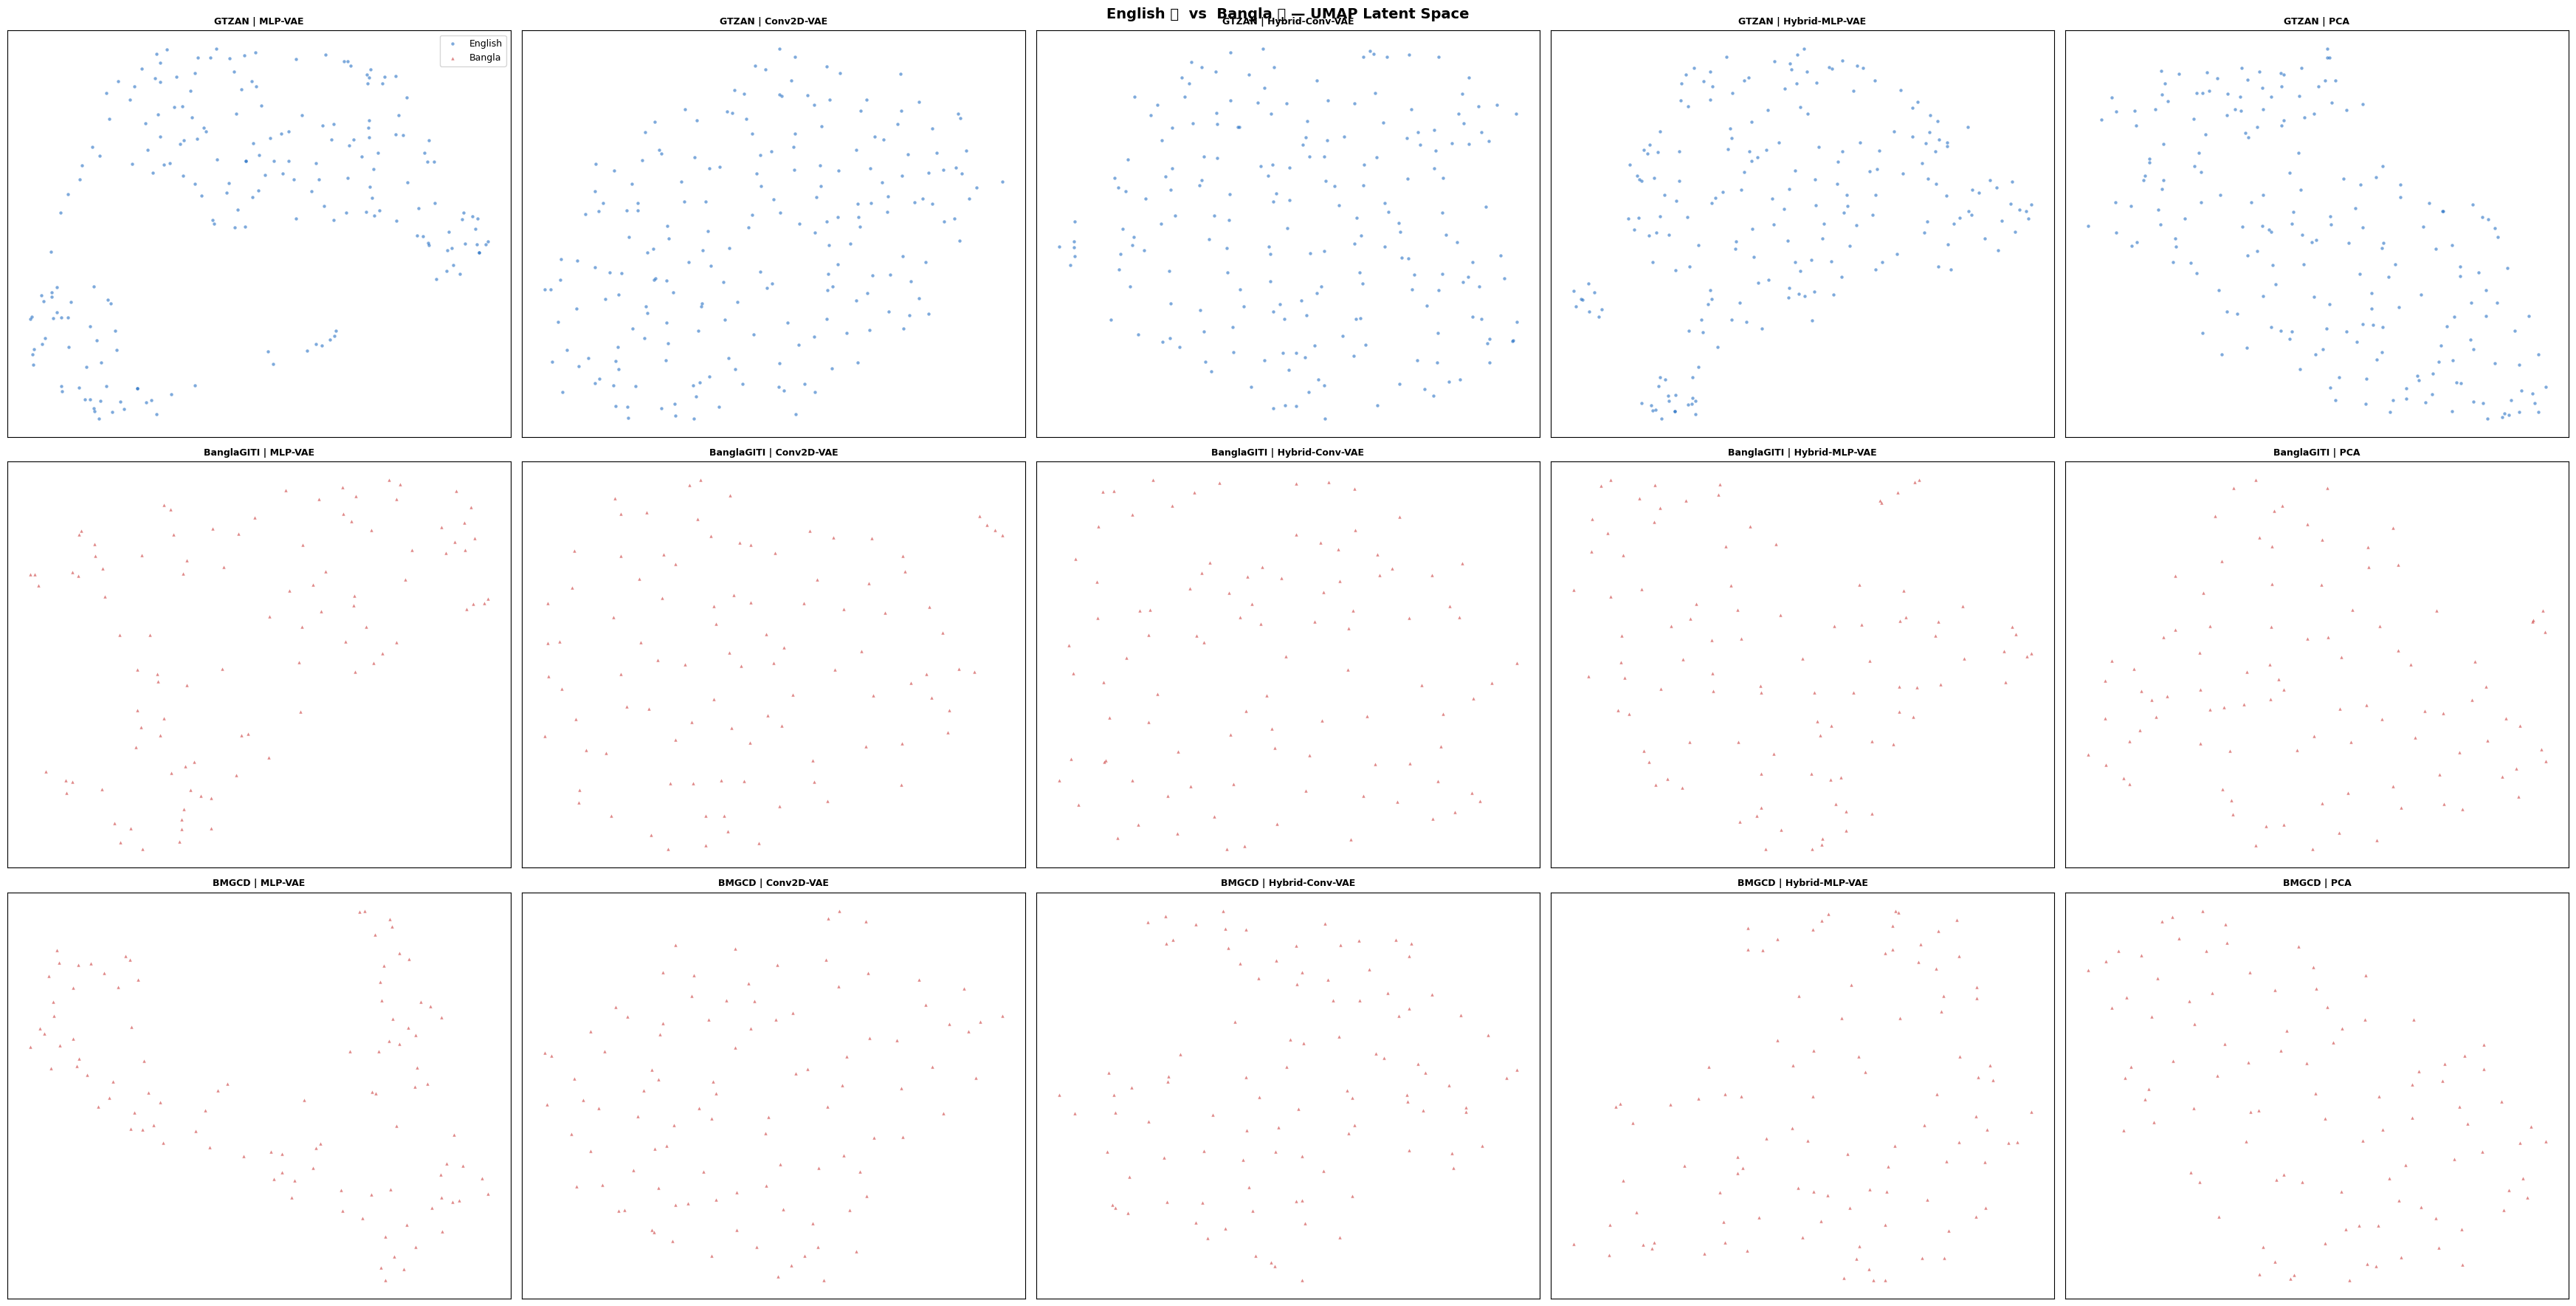

✅ Saved: language_separation.png


In [ ]:



fig, axes = plt.subplots(3, 5, figsize=(35, 18))  # 4→5 cols, width বাড়াও
fig.suptitle('English 🔵  vs  Bangla 🔴 — UMAP Latent Space', fontsize=14, fontweight='bold')
for row, (key, res) in enumerate(all_results.items()):
    for col, zkey in enumerate(['mlp','conv','hybrid','hybrid_mlp','pca']):  # hybrid_mlp যোগ
        ax=axes[row,col]; Z2=res['vis'][zkey]['umap']; lang=res['lang_labels']
        for lng in ['English','Bangla']:
            mask=lang==lng
            ax.scatter(Z2[mask,0],Z2[mask,1],c=LANG_COL[lng],marker=LANG_MK[lng],
                       s=10,alpha=0.55,label=lng,linewidths=0)
        ax.set_title(f'{key} | {MODEL_LABELS[zkey]}',fontsize=9,fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(alpha=0.15)
        if row==0 and col==0: ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/language_separation.png', dpi=130, bbox_inches='tight')
plt.show(); print('✅ Saved: language_separation.png')

## 🔥 Step 18: Metrics Heatmap Dashboard (5 Metrics)

In [ ]:



rows = []
for ds_key, res in all_results.items():
    for zkey, zlab in [('mlp','MLP-VAE'),('conv','Conv2D-VAE'),
                       ('hybrid','Hybrid-Conv-VAE'),
                       ('hybrid_mlp','Hybrid-MLP-VAE'),  # যোগ
                       ('pca','PCA')]:
        for algo in ['KMeans','Agglomerative','DBSCAN']:
            r = res['cl'][zkey][algo]
            rows.append({
                'Dataset':ds_key, 'Features':zlab, 'Algorithm':algo,
                'Silhouette':    round(r['sil'],4) if not np.isnan(r['sil']) else np.nan,
                'Davies-Bouldin':round(r['db'],4)  if not np.isnan(r['db'])  else np.nan,
                'Calinski-H':   round(r['ch'],1)   if not np.isnan(r['ch'])   else np.nan,
                'ARI':          round(r['ari'],4)  if not np.isnan(r['ari'])  else np.nan,
                'NMI':          round(r['nmi'],4)  if not np.isnan(r['nmi'])  else np.nan,
            })

df_all = pd.DataFrame(rows)
pd.set_option('display.max_rows', 200); pd.set_option('display.width', 200)
print('='*95)
print('  FULL METRICS TABLE  |  Silhouette↑  Davies-Bouldin↓  Calinski-H↑  ARI↑  NMI↑')
print('='*95)
print(df_all.to_string(index=False))
df_all.to_csv(f'{OUTPUT_DIR}/full_metrics.csv', index=False)
print('\n✅ Saved: full_metrics.csv')


feat_order = ['MLP-VAE','Conv2D-VAE','Hybrid-Conv-VAE','Hybrid-MLP-VAE','PCA']  # যোগ
metrics_cfg = [
    ('Silhouette',    '↑ higher', 'Blues'),
    ('Davies-Bouldin','↓ lower',  'Reds_r'),
    ('Calinski-H',    '↑ higher', 'Greens'),
    ('ARI',           '↑ higher', 'Purples'),
    ('NMI',           '↑ higher', 'Oranges'),
]
fig, axes = plt.subplots(2, 3, figsize=(26, 16))
fig.suptitle('Clustering Quality Heatmap — All 5 Metrics\nRows=Dataset+Algorithm | Cols=Feature Space',
             fontsize=14, fontweight='bold')
for ax, (metric, note, cmap) in zip(list(axes.flat)[:5], metrics_cfg):
    pivot = df_all.pivot_table(index=['Dataset','Algorithm'], columns='Features',
                               values=metric, aggfunc='mean')
    cols = [c for c in feat_order if c in pivot.columns]
    sns.heatmap(pivot[cols].astype(float), ax=ax, annot=True, fmt='.3f',
                cmap=cmap, linewidths=0.4, linecolor='white', cbar_kws={'shrink':0.8})
    ax.set_title(f'{metric}  ({note})', fontweight='bold', fontsize=11)
    ax.set_xlabel('Feature Space'); ax.tick_params(axis='x', rotation=20)
list(axes.flat)[-1].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); print('✅ Saved: metrics_heatmap.png')

## 📊 Step 19: Best Metrics Bar Charts

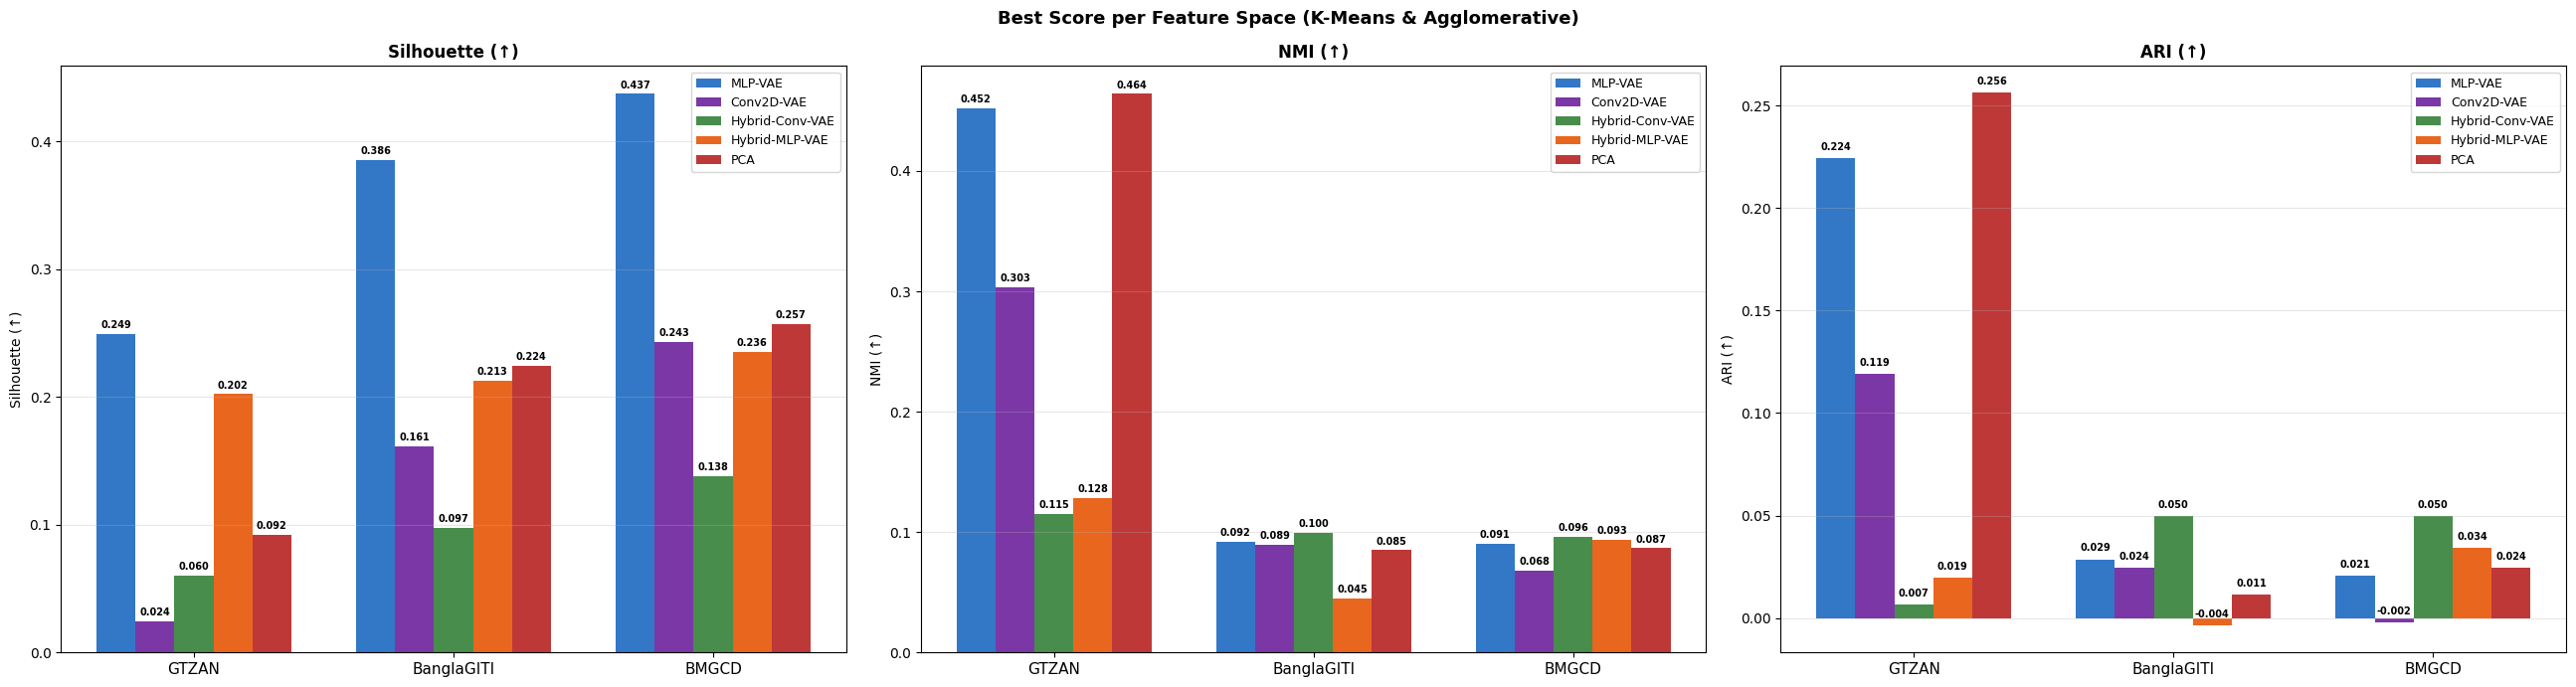

✅ Saved: best_metrics_bar.png


In [ ]:


feat_cols = ['MLP-VAE','Conv2D-VAE','Hybrid-Conv-VAE','Hybrid-MLP-VAE','PCA']  # update
datasets  = list(all_results.keys()); x = np.arange(len(datasets)); w = 0.15  # w 0.2→0.15

summary = []
for ds_key, res in all_results.items():
    for zkey, zlab in [('mlp','MLP-VAE'),('conv','Conv2D-VAE'),
                       ('hybrid','Hybrid-Conv-VAE'),
                       ('hybrid_mlp','Hybrid-MLP-VAE'),  # যোগ
                       ('pca','PCA')]:
        def _b(m, fn):
            v=[res['cl'][zkey][a][m] for a in ['KMeans','Agglomerative'] if not np.isnan(res['cl'][zkey][a][m])]
            return fn(v) if v else np.nan
        summary.append({'Dataset':ds_key,'Features':zlab,
                        'Best Sil':_b('sil',max),'Best NMI':_b('nmi',max),'Best ARI':_b('ari',max)})
df_sum = pd.DataFrame(summary)

fig, axes = plt.subplots(1, 3, figsize=(26, 7))  # width 22→26
fig.suptitle('Best Score per Feature Space (K-Means & Agglomerative)', fontsize=13, fontweight='bold')
for ax, (metric, ylabel) in zip(axes,[('Best Sil','Silhouette (↑)'),('Best NMI','NMI (↑)'),('Best ARI','ARI (↑)')]):
    for fi, feat in enumerate(feat_cols):
        vals = [df_sum[(df_sum.Dataset==d)&(df_sum.Features==feat)][metric].values[0] for d in datasets]
        bars = ax.bar(x+fi*w-2*w, vals, w, label=feat, color=COLORS_M[feat], alpha=0.88)  # 1.5*w→2*w
        for bar,v in zip(bars,vals):
            if not np.isnan(v): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                                        f'{v:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(datasets, fontsize=11)
    ax.set_ylabel(ylabel); ax.set_title(ylabel, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/best_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show(); print('✅ Saved: best_metrics_bar.png')

## 📉 Step 20: Training Loss Curves

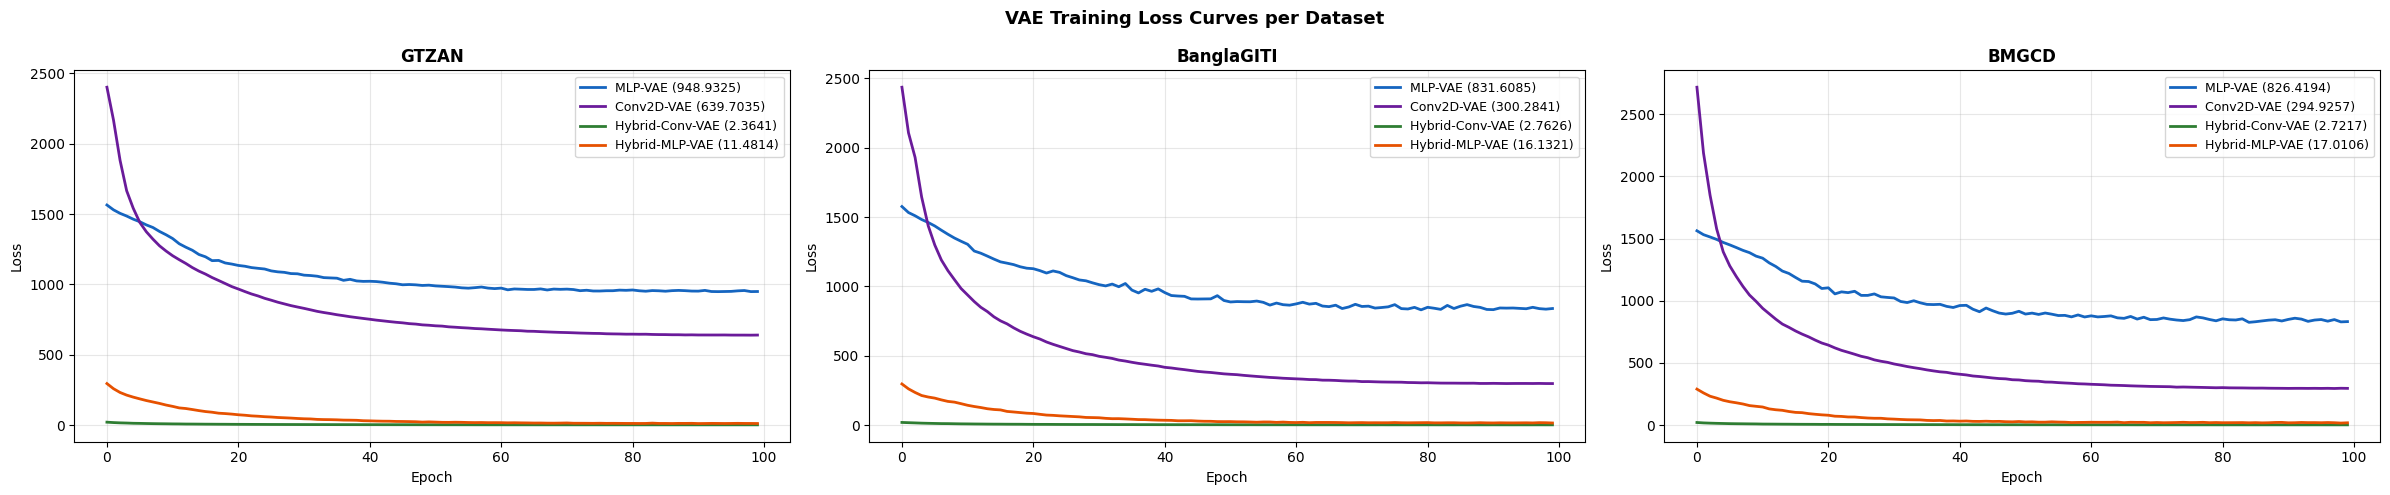

✅ Saved: training_curves.png


In [ ]:


MODEL_COLORS = {
    'mlp':        '#1565C0',
    'conv':       '#6A1B9A',
    'hybrid':     '#2E7D32',
    'hybrid_mlp': '#E65100',  # যোগ
}
fig, axes = plt.subplots(1, 3, figsize=(24, 5))  # width 20→24
fig.suptitle('VAE Training Loss Curves per Dataset', fontsize=13, fontweight='bold')
for ax, (key, res) in zip(axes, all_results.items()):
    for mkey, color in MODEL_COLORS.items():
        ax.plot(res['hist'][mkey], color=color, linewidth=2,
                label=f'{MODEL_LABELS[mkey]} ({res["loss"][mkey]:.4f})')
    ax.set_title(key, fontweight='bold'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show(); print('✅ Saved: training_curves.png')

In [ ]:
MODEL_COLORS = {
    'mlp':        '#1565C0',
    'conv':       '#6A1B9A',
    'hybrid':     '#2E7D32',
    'hybrid_mlp': '#E65100',
}

# ── 3 rows: Total | Recon | KL  ×  3 datasets ─────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(24, 14))
fig.suptitle('VAE Training Loss Curves per Dataset', fontsize=14, fontweight='bold')

row_keys   = ['total', 'recon', 'kl']
row_labels = ['Total Loss', 'Reconstruction Loss', 'KL Divergence']

for col, (key, res) in enumerate(all_results.items()):
    for row, (loss_key, row_label) in enumerate(zip(row_keys, row_labels)):
        ax = axes[row, col]
        for mkey, color in MODEL_COLORS.items():
            # expects res['hist'][mkey] to be a dict: {'total':[], 'recon':[], 'kl':[]}
            curve = res['hist'][mkey][loss_key]
            final = curve[-1]
            ax.plot(curve, color=color, linewidth=2,
                    label=f'{MODEL_LABELS[mkey]} ({final:.4f})')

        if row == 0:
            ax.set_title(key, fontweight='bold', fontsize=11)
        if col == 0:
            ax.set_ylabel(row_label, fontsize=10)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: training_curves.png')



## 🔬 Step 21: VAE vs PCA Baseline — Δ Analysis  *(NEW)*

**Positive bar** = VAE beats PCA baseline on that metric.

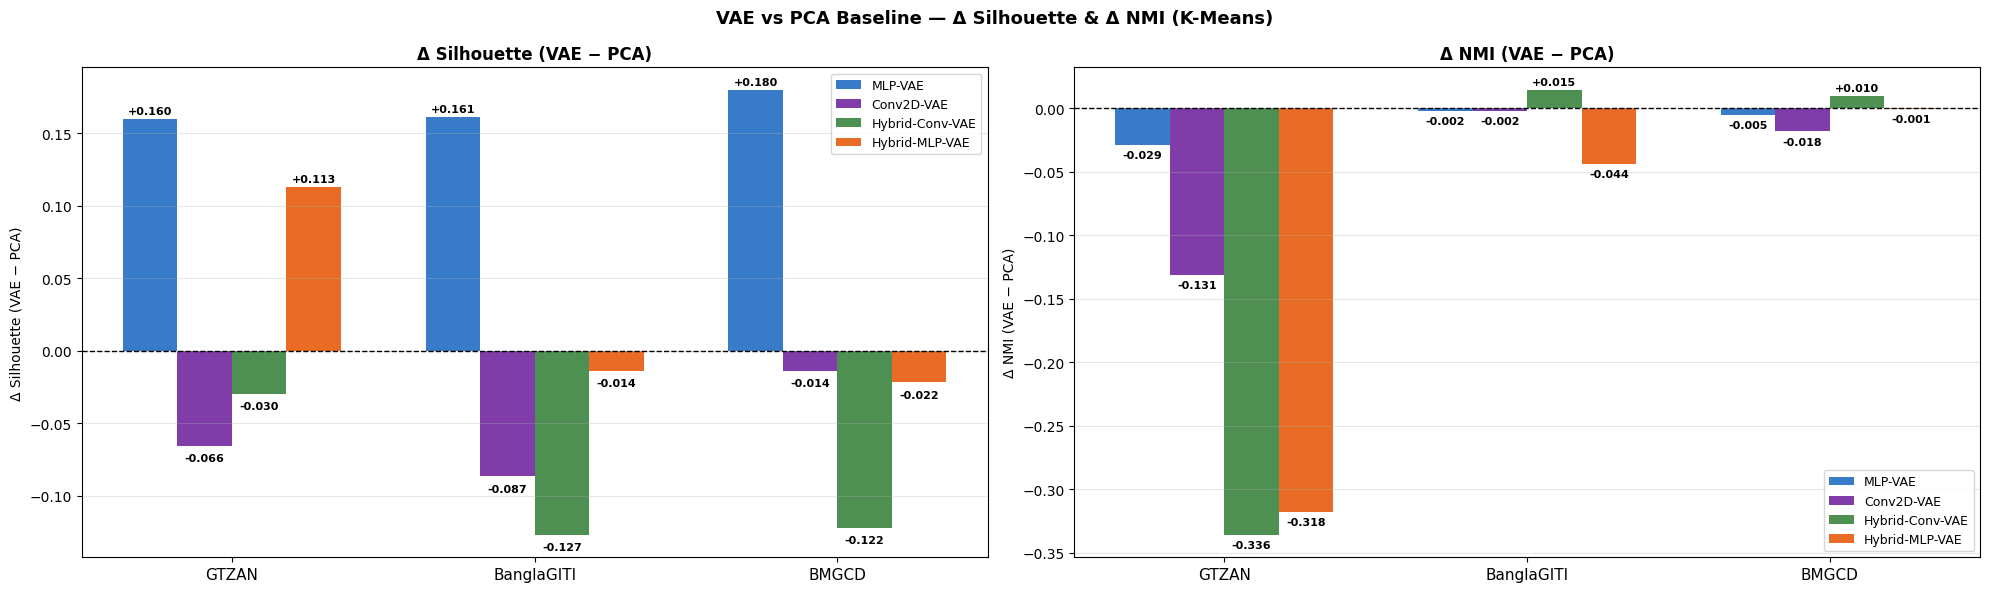

✅ Saved: vae_vs_baseline.png


In [ ]:



vae_keys = [('mlp','MLP-VAE'),('conv','Conv2D-VAE'),
            ('hybrid','Hybrid-Conv-VAE'),
            ('hybrid_mlp','Hybrid-MLP-VAE')]  # যোগ
x = np.arange(len(datasets)); w = 0.18  # 0.25→0.18
fig, axes = plt.subplots(1, 2, figsize=(20, 6))  # width 16→20
fig.suptitle('VAE vs PCA Baseline — Δ Silhouette & Δ NMI (K-Means)', fontsize=13, fontweight='bold')
for ax, metric in zip(axes, ['sil','nmi']):
    ylabel = 'Δ Silhouette (VAE − PCA)' if metric=='sil' else 'Δ NMI (VAE − PCA)'
    for fi, (zkey, zlabel) in enumerate(vae_keys):
        deltas = [res['cl'][zkey]['KMeans'][metric] - res['cl']['pca']['KMeans'][metric]
                  for res in all_results.values()]
        bars = ax.bar(x+fi*w-1.5*w, deltas, w, label=zlabel, color=COLORS_M[zlabel], alpha=0.85)  # -w→-1.5*w
        for bar,v in zip(bars,deltas):
            if not np.isnan(v):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(0.002 if v>=0 else -0.012),
                        f'{v:+.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_xticks(x); ax.set_xticklabels(datasets, fontsize=11)
    ax.set_ylabel(ylabel); ax.set_title(ylabel, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/vae_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show(); print('✅ Saved: vae_vs_baseline.png')

## 📋 Step 23: Quantitative Analysis & Interpretation

In [ ]:
# FIX #5: hybrid_mlp was computed but silently excluded from this analysis.
# Added to all comparison loops so all 4 VAE variants are reported.

print('='*80)
print('  ANALYSIS: All VAE Variants vs PCA Baseline (K-Means, Silhouette + NMI)')
print('='*80)
for ds_key, res in all_results.items():
    print(f'\n  Dataset: {ds_key}')
    print(f'  {"":-<76}')
    pca_sil = res['cl']['pca']['KMeans']['sil']
    pca_nmi = res['cl']['pca']['KMeans']['nmi']
    # FIX #5: was ['mlp','conv','hybrid'] — hybrid_mlp added
    for zkey, zlab in [('mlp','MLP-VAE'),('conv','Conv2D-VAE'),
                       ('hybrid','Hybrid-Conv-VAE'),
                       ('hybrid_mlp','Hybrid-MLP-VAE')]:
        vae_sil = res['cl'][zkey]['KMeans']['sil']
        vae_nmi = res['cl'][zkey]['KMeans']['nmi']
        d_sil = vae_sil - pca_sil; d_nmi = vae_nmi - pca_nmi
        pct   = d_sil/abs(pca_sil)*100 if pca_sil!=0 else 0
        v = 'BETTER ✅' if d_sil>0.005 else ('WORSE  ❌' if d_sil<-0.005 else 'SIMILAR ~')
        print(f'  {ds_key:<12} | {zlab:<18} | Sil: {vae_sil:.4f} vs PCA {pca_sil:.4f} '
              f'Δ={d_sil:+.4f}({pct:+.1f}%)  NMI Δ={d_nmi:+.4f}  {v}')

print()
print('INTERPRETATION')
print('─'*70)
print('✅ VAE BETTER  → Non-linear encoder captures manifold structure PCA cannot.')
print('   When: high-dim data, complex genre boundaries, entangled audio features.')
print()
print('❌ VAE WORSE   → Small dataset (VAE overfits latent space), very low-dim')
print('   data (PCA near-lossless), or β too high (over-regularised latent space).')
print()
print('Conv2D-VAE captures LOCAL time-frequency correlations between adjacent bins.')
print('Hybrid adds orthogonal genre-text signal via TF-IDF/LSA — most discriminative')
print('when audio features alone are genre-ambiguous (e.g. classical vs jazz).')
print()
print('Hybrid-MLP-VAE vs Hybrid-Conv-VAE: the latter first encodes the full 2D')
print('spectrogram structure, then fuses with lyrics → richer audio representation.')
print()
print('NMI: symmetric, invariant to label permutations, corrects for cluster size.')
print('ARI: corrects for random labelling. Both ↑ = better genre alignment.')
print()
print('ℹ️  GTZAN lyrics: all seed-based (filenames like blues.00042.wav have no title).')
print('   Hybrid gain on GTZAN reflects genre-vocabulary signal, not scraped lyrics.')


  ANALYSIS: All VAE Variants vs PCA Baseline (K-Means, Silhouette + NMI)

  Dataset: GTZAN
  ----------------------------------------------------------------------------
  GTZAN        | MLP-VAE            | Sil: 0.2494 vs PCA 0.0897 Δ=+0.1598(+178.2%)  NMI Δ=-0.0288  BETTER ✅
  GTZAN        | Conv2D-VAE         | Sil: 0.0241 vs PCA 0.0897 Δ=-0.0655(-73.1%)  NMI Δ=-0.1312  WORSE  ❌
  GTZAN        | Hybrid-Conv-VAE    | Sil: 0.0600 vs PCA 0.0897 Δ=-0.0297(-33.1%)  NMI Δ=-0.3361  WORSE  ❌
  GTZAN        | Hybrid-MLP-VAE     | Sil: 0.2022 vs PCA 0.0897 Δ=+0.1126(+125.6%)  NMI Δ=-0.3179  BETTER ✅

  Dataset: BanglaGITI
  ----------------------------------------------------------------------------
  BanglaGITI   | MLP-VAE            | Sil: 0.3856 vs PCA 0.2245 Δ=+0.1611(+71.8%)  NMI Δ=-0.0024  BETTER ✅
  BanglaGITI   | Conv2D-VAE         | Sil: 0.1377 vs PCA 0.2245 Δ=-0.0868(-38.7%)  NMI Δ=-0.0020  WORSE  ❌
  BanglaGITI   | Hybrid-Conv-VAE    | Sil: 0.0973 vs PCA 0.2245 Δ=-0.1272(-56.6%)  N

## 📋 Step 24: Final Summary Report


In [ ]:
SEP = '='*80
print(SEP)
print('  ENHANCED Conv2D-VAE CLUSTERING — FINAL REPORT  (Medium Task)')
print('  3 Datasets: GTZAN · BanglaGITI · BMGCD')
print('  5 Feature Spaces × 3 Algorithms × 5 Metrics | No Synthetic Audio Data')
print(SEP)
for ds_key, res in all_results.items():
    print(f'\n  {res["name"]}  |  {len(res["y_labels"])} samples  {res["n_class"]} genres')
    print(f'  {"Features":<20} {"Algorithm":<16} {"Sil":>7} {"DB(↓)":>7} {"CH":>9} {"ARI":>7} {"NMI":>7}')
    print('  '+'-'*73)
    # FIX #5: was missing hybrid_mlp — now all 5 feature spaces reported
    for zkey, zlab in [('mlp','MLP-VAE'),('conv','Conv2D-VAE'),
                       ('hybrid','Hybrid-Conv-VAE'),
                       ('hybrid_mlp','Hybrid-MLP-VAE'),
                       ('pca','PCA')]:
        for algo in ['KMeans','Agglomerative','DBSCAN']:
            r = res['cl'][zkey][algo]
            _f = lambda v: f'{v:.4f}' if not (isinstance(v,float) and __import__("math").isnan(v)) else '  N/A '
            print(f'  {zlab:<20} {algo:<16} {_f(r["sil"]):>7} {_f(r["db"]):>7} '
                  f'{_f(r["ch"]):>9} {_f(r["ari"]):>7} {_f(r["nmi"]):>7}')
print()
print(SEP)
print('  LYRICS COVERAGE SUMMARY')
print(SEP)
for ds_key, res in all_results.items():
    n_real = sum(res.get('has_real_lyrics', []))
    n_total = len(res['y_labels'])
    pct = 100*n_real/max(n_total,1)
    print(f'  {ds_key:<12}: {n_real:>4}/{n_total} real lyrics ({pct:.1f}%) '
          f'| {n_total-n_real} genre-seed fallback')
print()
print('  Note: GTZAN lyrics are 100% genre-seed based (numeric filenames = no title).')
print('  BanglaGITI/BMGCD: real lyrics scraped where available (gaanesuno.com).')


  ENHANCED Conv2D-VAE CLUSTERING — FINAL REPORT  (Medium Task)
  3 Datasets: GTZAN · BanglaGITI · BMGCD
  5 Feature Spaces × 3 Algorithms × 5 Metrics | No Synthetic Audio Data

  GTZAN (English Multi-Genre)  |  200 samples  10 genres
  Features             Algorithm            Sil   DB(↓)        CH     ARI     NMI
  -------------------------------------------------------------------------
  MLP-VAE              KMeans            0.2494  1.1581   57.0511  0.1902  0.4057
  MLP-VAE              Agglomerative     0.2366  1.1266   52.1588  0.2245  0.4523
  MLP-VAE              DBSCAN              N/A     N/A       N/A     N/A     N/A 
  Conv2D-VAE           KMeans            0.0241  2.4896    5.5946  0.1192  0.3032
  Conv2D-VAE           Agglomerative     0.0067  2.7355    5.2659  0.0909  0.2694
  Conv2D-VAE           DBSCAN              N/A     N/A       N/A     N/A     N/A 
  Hybrid-Conv-VAE      KMeans            0.0600  2.5578    8.8846 -0.0022  0.0983
  Hybrid-Conv-VAE      Agglomerati

## 📥 Step 25: Download All Results

In [ ]:
import shutil
shutil.make_archive('/content/vae_medium_results', 'zip', OUTPUT_DIR)
from google.colab import files
files.download('/content/vae_medium_results.zip')
print('✅ Download started!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!
